In [1]:
import pandas as pd

df_constraints = pd.read_csv("merged_constraints_only.csv")

`merged_constraints_only.csv` comes from the filter from all raw edits. Given a plain export file, we first do one pass to check te occurrences of `p=ps:P2302` and collect the object values `wds:PID`. We make then a second pass collecting all triples where these `wds:PID` appear as subjects. Therefore, `merged_constraints_only.csv` contains a merged file for all other files including: (1) the triples where `p=ps:P2302` and (2) the triples where `s=wds:PID`

In [2]:
df_constraints.dtypes

s        object
p        object
o        object
cdate    object
cuser    object
ddate    object
duser    object
dtype: object

In [3]:
df_constraints.head(20)

,s,p,o,cdate,cuser,ddate,duser
0,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,pq:P2305,wd:Q130964,2018-10-10T20:01:07Z,Astirmays,2018-12-13T10:23:06Z,Jura1
1,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,ps:P2302,wd:Q21514353,2018-10-10T19:55:29Z,Astirmays,2018-12-13T10:23:06Z,Jura1
2,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,pq:P2305,wd:Q25269,2018-10-10T20:01:07Z,Astirmays,2018-12-13T10:23:06Z,Jura1
3,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,wikibase:rank,wikibase:NormalRank,2018-10-10T19:55:29Z,Astirmays,2018-12-13T10:23:06Z,Jura1
4,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,pq:P2305,wd:Q296936,2018-10-10T20:01:07Z,Astirmays,2018-12-13T10:23:06Z,Jura1
5,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,pq:P2305,wd:Q182098,2018-10-10T20:01:07Z,Astirmays,2018-12-13T10:23:06Z,Jura1
6,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,pq:P2305,wd:Q26708069,2018-10-10T20:01:07Z,Astirmays,2018-12-13T10:23:06Z,Jura1
7,wd:Q11379,p:P2302,wds:Q11379-10e45eb7-44c3-366f-51c7-c33f0b28ba32,2018-10-10T19:55:29Z,Astirmays,2018-12-13T10:23:06Z,Jura1
8,wds:q11749-e7180d65-4c2a-95b5-d234-7009dca12da4,ps:P2302,wd:Q19474404,2023-04-24T07:13:06Z,Tomodachi94,2023-04-24T07:14:17Z,Tomodachi94
9,wd:Q11749,p:P2302,wds:q11749-e7180d65-4c2a-95b5-d234-7009dca12da4,2023-04-24T07:13:06Z,Tomodachi94,2023-04-24T07:14:17Z,Tomodachi94


In [4]:
mask_q_subject = df_constraints["s"].str.match(r"^(wd|wds):q", case=False, na=False)

mask_wds_q_subject = df_constraints["s"].str.match(r"^wds:q", case=False, na=False)

distinct_wds_q_subjects = (
    df_constraints.loc[mask_wds_q_subject, "s"]
    .str.lower()
    .nunique()
)

df_constraints_clean = df_constraints.loc[~mask_q_subject].copy()

print("Distinct wds:Q statement subjects:", distinct_wds_q_subjects)
print("Removed rows:", mask_q_subject.sum())
print("Rows after removal:", len(df_constraints_clean))

Distinct wds:Q statement subjects: 333
Removed rows: 1496
Rows after removal: 464409


Q: Out of the wrongly created PCs for QIDs, how many still exist?

A: 2, check the result of the code below

In [5]:
removed = df_constraints.loc[mask_q_subject].copy()

removed_without_ddate = removed[
    removed["ddate"].isna() | removed["ddate"].astype(str).str.strip().eq("")
]

print("Removed rows without ddate:", len(removed_without_ddate))
print("Distinct removed wds:Q subjects without ddate:",
      removed_without_ddate.loc[
          removed_without_ddate["s"].str.match(r"^wds:q", case=False, na=False),
          "s"
      ].str.lower().nunique())

removed_without_ddate.head()

Removed rows without ddate: 8
Distinct removed wds:Q subjects without ddate: 2


,s,p,o,cdate,cuser,ddate,duser
382265,wds:Q133294509-b312d72d-4fc9-a156-d58c-c833dda...,ps:P2302,wd:Q21514353,2025-03-16T20:10:11Z,Jlefevre76,NaN,NaN
382266,wd:Q133294509,p:P2302,wds:Q133294509-b312d72d-4fc9-a156-d58c-c833dda...,2025-03-16T20:10:11Z,Jlefevre76,NaN,NaN
382267,wds:Q133294509-b312d72d-4fc9-a156-d58c-c833dda...,wikibase:rank,wikibase:NormalRank,2025-03-16T20:10:11Z,Jlefevre76,NaN,NaN
382268,wds:Q133294509-b312d72d-4fc9-a156-d58c-c833dda...,pq:P2305,wd:Q133294676,2025-03-16T20:10:11Z,Jlefevre76,NaN,NaN
410522,wd:Q1932823,p:P2302,wds:Q1932823-443084fb-4320-18fe-07ea-9355106ea004,2025-01-21T14:34:16Z,Nate Wessel,NaN,NaN


In [6]:
df_constraints_clean

,s,p,o,cdate,cuser,ddate,duser
73,wd:P484,p:P2302,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
74,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,wikibase:rank,wikibase:NormalRank,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
76,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3817441,2017-07-13T04:20:45Z,KrBot,2017-07-13T23:44:20Z,KrBot
77,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3680919,2017-07-13T04:20:46Z,KrBot,2017-07-13T23:44:20Z,KrBot
...,...,...,...,...,...,...,...
465900,wds:P483-6F8D6505-49FF-4661-A7E0-B917CE794639,pq:P2308,wd:Q14350,2023-02-14T16:40:06Z,Sdkb,NaN,NaN
465901,wds:P483-6F8D6505-49FF-4661-A7E0-B917CE794639,pq:P2308,wd:Q18674739,2024-01-02T17:19:07Z,Vojtěch Dostál,NaN,NaN
465902,wds:P483-6F8D6505-49FF-4661-A7E0-B917CE794639,pq:P2308,wd:Q200538,2024-03-20T15:51:59Z,Dodro,NaN,NaN
465903,wds:P483-6F8D6505-49FF-4661-A7E0-B917CE794639,pq:P2308,wd:Q511355,2024-06-11T11:45:50Z,Moebeus,NaN,NaN


In [7]:
import json
import re
import pandas as pd
import ipaddress

with open("wikidata_bots.json", "r", encoding="utf-8") as f:
    wikidata_bots = json.load(f)

curated_bots = {name.casefold() for name in wikidata_bots}


def is_ip_address(user):
    if pd.isna(user):
        return False
    try:
        ipaddress.ip_address(str(user).strip())
        return True
    except ValueError:
        return False

def is_bot(user):
    if pd.isna(user):
        return False
    user = str(user).strip()
    u = user.casefold()
    return (
        u in curated_bots
        or u.endswith("bot")
        or u.startswith("bot")
    )

# Ignore rows with missing users OR IP addresses
mask_invalid = (
    df_constraints_clean["cuser"].isna()
    | df_constraints_clean["duser"].isna()
    | df_constraints_clean["cuser"].apply(is_ip_address)
    | df_constraints_clean["duser"].apply(is_ip_address)
)

df_user_pairs = df_constraints_clean.loc[~mask_invalid].copy()

df_user_pairs["creator_type"] = df_user_pairs["cuser"].apply(
    lambda x: "bot" if is_bot(x) else "human"
)

df_user_pairs["deleter_type"] = df_user_pairs["duser"].apply(
    lambda x: "bot" if is_bot(x) else "human"
)

change_counts = (
    df_user_pairs
    .groupby(["creator_type", "deleter_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["human", "bot"], columns=["human", "bot"], fill_value=0)
)

print(change_counts / len(df_constraints_clean))

deleter_type     human       bot
creator_type                    
human         0.130852  0.025249
bot           0.043688  0.066220


In [8]:
change_counts

deleter_type,human,bot
creator_type,,
human,60769,11726
bot,20289,30753


In [9]:
change_counts / change_counts.values.sum()

deleter_type,human,bot
creator_type,,
human,0.491909,0.094919
bot,0.164234,0.248938


So among constraint changes with valid non-IP creator and deleter users:

- 49.2% were human-created and human-removed
- 9.5% were human-created and bot-removed
- 16.4% were bot-created and human-removed
- 24.9% were bot-created and bot-removed

`fetch_wikidata_labels` was defined here but we decide to move on with a curated list extracted in April 2026 of all valid wikidata subclasses of property constraints. This list was also validated against other literature using wikidata property constraints [1].

[1] Ferranti, N., De Souza, J. F., Ahmetaj, S., & Polleres, A. (2024). Formalizing and validating Wikidata’s property constraints using SHACL and SPARQL. Semantic Web, 15(6), 2333-2380.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import requests


def fetch_wikidata_labels(qids, lang="en", endpoint="https://query.wikidata.org/sparql"):
    """
    Fetch labels for a list of Wikidata QIDs using the Wikidata SPARQL endpoint.

    Parameters
    ----------
    qids : iterable of str
        Example: ['wd:Q5', 'wd:Q42']
    lang : str, default 'en'
        Label language.
    endpoint : str
        Wikidata SPARQL endpoint.

    Returns
    -------
    dict
        Mapping like {'wd:Q5': 'human', 'wd:Q42': 'Douglas Adams'}
    """
    qids = [str(q).strip() for q in qids if pd.notna(q)]
    qids = list(dict.fromkeys(qids))  # preserve order, remove duplicates

    if not qids:
        return {}

    values = " ".join(qids)

    query = f"""
    SELECT ?s ?label WHERE {{
      VALUES ?s {{ {values} }}
      ?s rdfs:label ?label .
      FILTER (lang(?label) = "{lang}")
    }}
    """

    headers = {
        "Accept": "application/sparql-results+json",
        "User-Agent": "Mozilla/5.0 (compatible; pandas-visualization-script/1.0)"
    }

    response = requests.get(
        endpoint,
        params={"query": query, "format": "json"},
        headers=headers,
        timeout=30,
    )
    response.raise_for_status()
    data = response.json()

    label_map = {}
    for row in data["results"]["bindings"]:
        uri = row["s"]["value"]          # e.g. http://www.wikidata.org/entity/Q5
        label = row["label"]["value"]    # e.g. human
        qid = "wd:" + uri.rsplit("/", 1)[-1]
        label_map[qid] = label

    return label_map

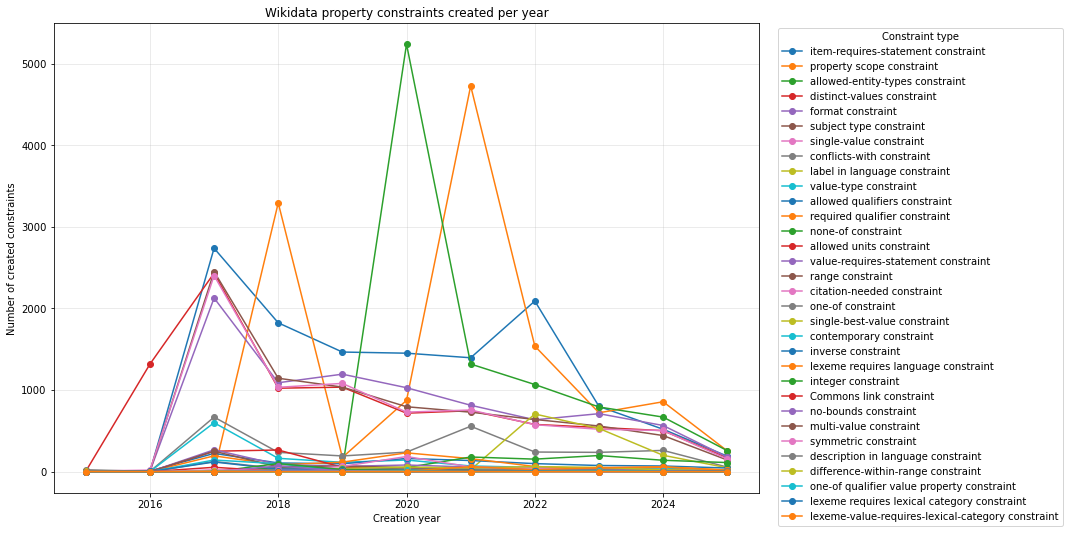

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load curated constraint types
with open("constraint_types.json", "r", encoding="utf-8") as f:
    constraint_types = json.load(f)

constraint_type_map = {
    "wd:" + item["cid"].rsplit("/", 1)[-1]: item["cidLabel"]
    for item in constraint_types
}

curated_constraint_qids = set(constraint_type_map)

# 2. Keep only constraint-type rows whose object is curated
df_created_constraints = df_constraints_clean.loc[
    df_constraints_clean["p"].eq("ps:P2302")
    & df_constraints_clean["o"].isin(curated_constraint_qids),
    ["o", "cdate"]
].copy()

# 3. Parse date and extract year
df_created_constraints["cdate"] = pd.to_datetime(
    df_created_constraints["cdate"],
    errors="coerce",
    utc=True
)

df_created_constraints = df_created_constraints.dropna(subset=["cdate", "o"])
df_created_constraints["year"] = df_created_constraints["cdate"].dt.year
df_created_constraints["constraint_label"] = df_created_constraints["o"].map(constraint_type_map)

# 4. Aggregate per year and constraint type
created_pivot = (
    df_created_constraints
    .groupby(["year", "constraint_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Optional: order curves by total number of creations
created_pivot = created_pivot[
    created_pivot.sum().sort_values(ascending=False).index
]

# 5. Plot curves
ax = created_pivot.plot(
    kind="line",
    marker="o",
    figsize=(15, 8)
)

ax.set_title("Wikidata property constraints created per year")
ax.set_xlabel("Creation year")
ax.set_ylabel("Number of created constraints")
ax.legend(
    title="Constraint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

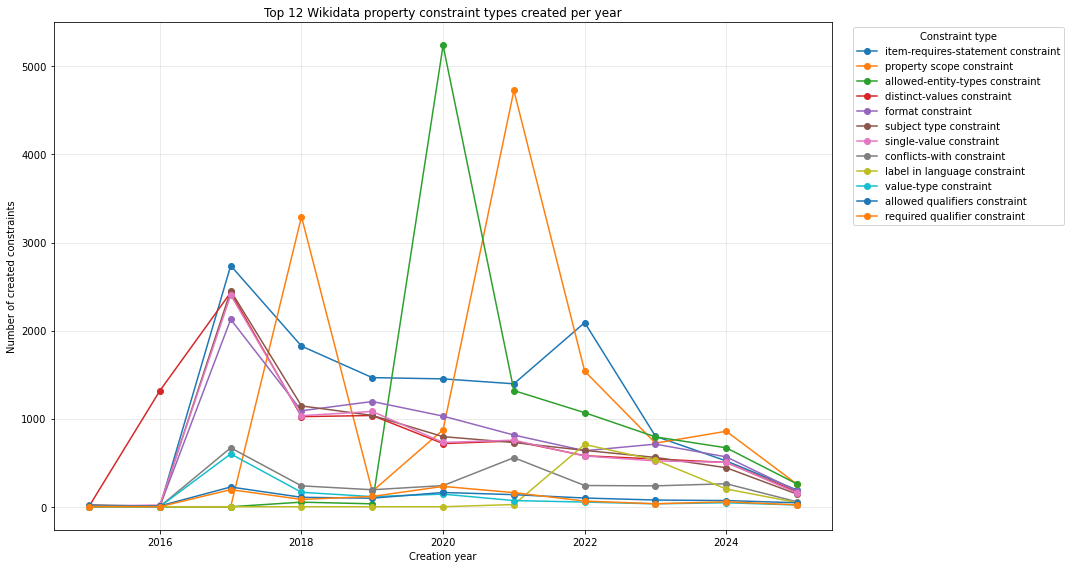

In [12]:
top_n = 12
top_labels = created_pivot.sum().sort_values(ascending=False).head(top_n).index

ax = created_pivot[top_labels].plot(
    kind="line",
    marker="o",
    figsize=(15, 8)
)

ax.set_title(f"Top {top_n} Wikidata property constraint types created per year")
ax.set_xlabel("Creation year")
ax.set_ylabel("Number of created constraints")
ax.legend(
    title="Constraint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


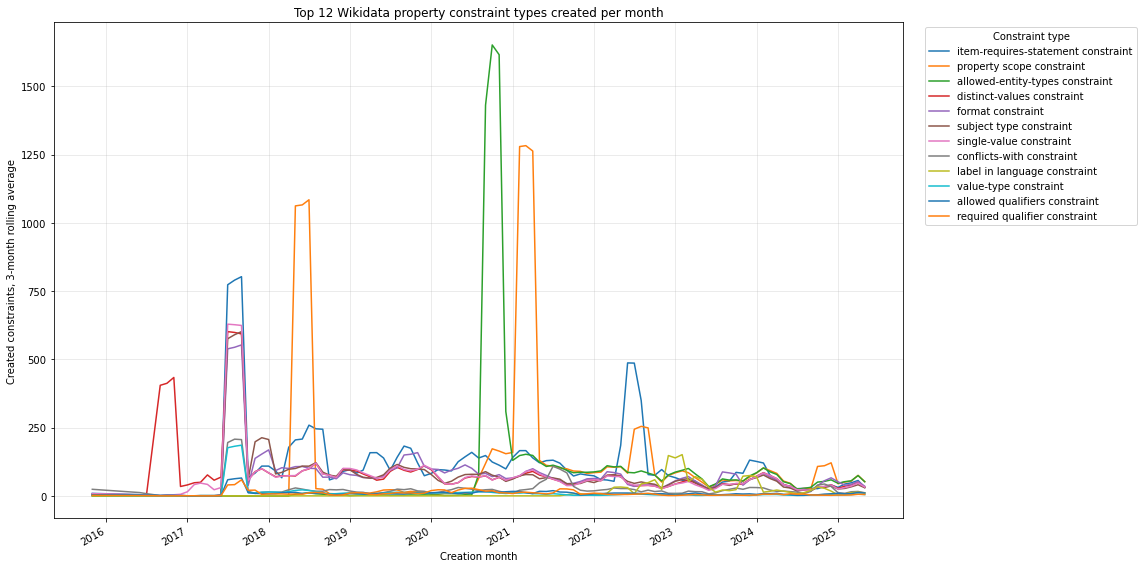

In [13]:
# Monthly aggregation
df_created_constraints["month"] = (
    df_created_constraints["cdate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

created_monthly = (
    df_created_constraints
    .groupby(["month", "constraint_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Optional: keep only top N constraint types
top_n = 12
top_labels = created_monthly.sum().sort_values(ascending=False).head(top_n).index

# Smooth with rolling average, e.g. 3-month window
created_monthly_smoothed = (
    created_monthly[top_labels]
    .rolling(window=3, min_periods=1)
    .mean()
)

ax = created_monthly_smoothed.plot(
    kind="line",
    figsize=(16, 8)
)

ax.set_title(f"Top {top_n} Wikidata property constraint types created per month")
ax.set_xlabel("Creation month")
ax.set_ylabel("Created constraints, 3-month rolling average")
ax.legend(
    title="Constraint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/opt/conda/lib/python3.10/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


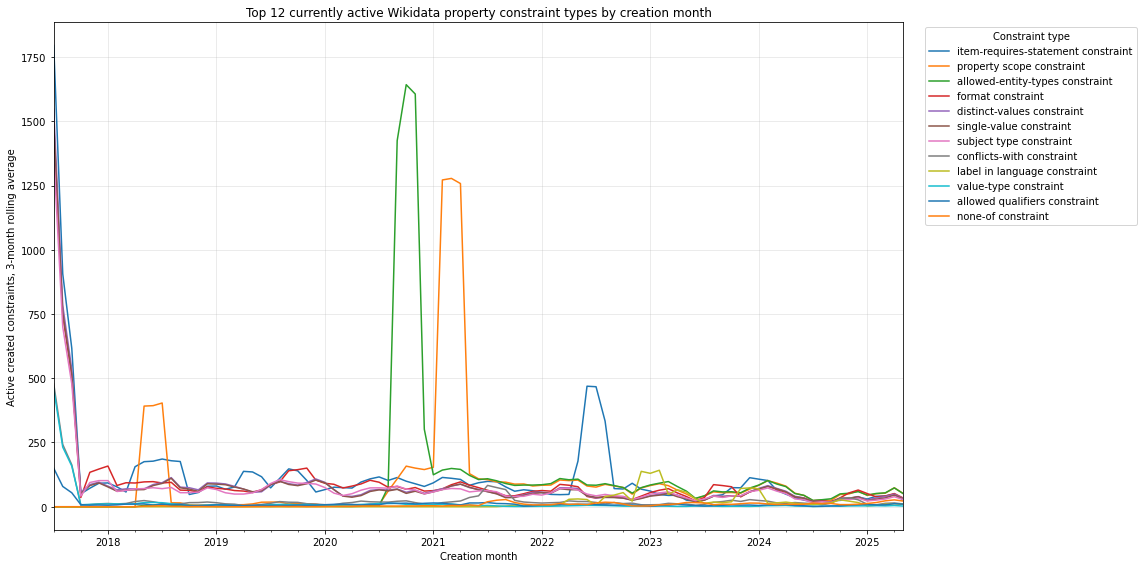

In [14]:
# Keep only active / not-deleted curated constraint-type rows
df_created_constraints_active = df_constraints_clean.loc[
    df_constraints_clean["p"].eq("ps:P2302")
    & df_constraints_clean["o"].isin(curated_constraint_qids)
    & df_constraints_clean["ddate"].isna(),
    ["o", "cdate"]
].copy()

df_created_constraints_active["cdate"] = pd.to_datetime(
    df_created_constraints_active["cdate"],
    errors="coerce",
    utc=True
)

df_created_constraints_active = df_created_constraints_active.dropna(subset=["cdate", "o"])

df_created_constraints_active["constraint_label"] = (
    df_created_constraints_active["o"].map(constraint_type_map)
)

df_created_constraints_active["month"] = (
    df_created_constraints_active["cdate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

created_monthly_active = (
    df_created_constraints_active
    .groupby(["month", "constraint_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

top_n = 12
top_labels = (
    created_monthly_active
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

created_monthly_active_smoothed = (
    created_monthly_active[top_labels]
    .rolling(window=3, min_periods=1)
    .mean()
)

ax = created_monthly_active_smoothed.plot(
    kind="line",
    figsize=(16, 8)
)

ax.set_title(
    f"Top {top_n} currently active Wikidata property constraint types by creation month"
)
ax.set_xlabel("Creation month")
ax.set_ylabel("Active created constraints, 3-month rolling average")
ax.legend(
    title="Constraint type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Keep only:
# - actual constraint type rows: p == ps:P2302
# - curated constraint types
# - constraints that were not deleted: ddate is NaN
# - rows with non-missing, non-IP creators

df_active_created = df_constraints_clean.loc[
    df_constraints_clean["p"].eq("ps:P2302")
    & df_constraints_clean["o"].isin(curated_constraint_qids)
    & df_constraints_clean["ddate"].isna()
    & df_constraints_clean["cuser"].notna()
    & ~df_constraints_clean["cuser"].apply(is_ip_address),
    ["o", "cdate", "cuser"]
].copy()

In [16]:
# Parse dates and enrich with labels / months / creator type

df_active_created["cdate"] = pd.to_datetime(
    df_active_created["cdate"],
    errors="coerce",
    utc=True
)

df_active_created = df_active_created.dropna(subset=["cdate", "o"])

df_active_created["constraint_label"] = df_active_created["o"].map(constraint_type_map)

df_active_created["month"] = (
    df_active_created["cdate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

df_active_created["creator_type"] = df_active_created["cuser"].apply(
    lambda x: "bot" if is_bot(x) else "human"
)

/opt/conda/lib/python3.10/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


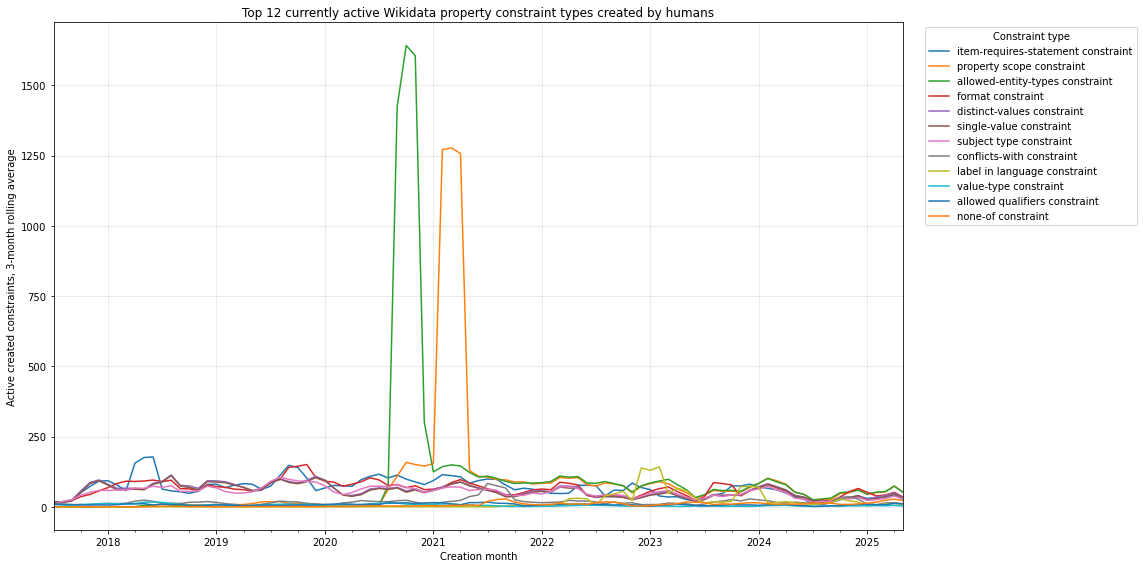

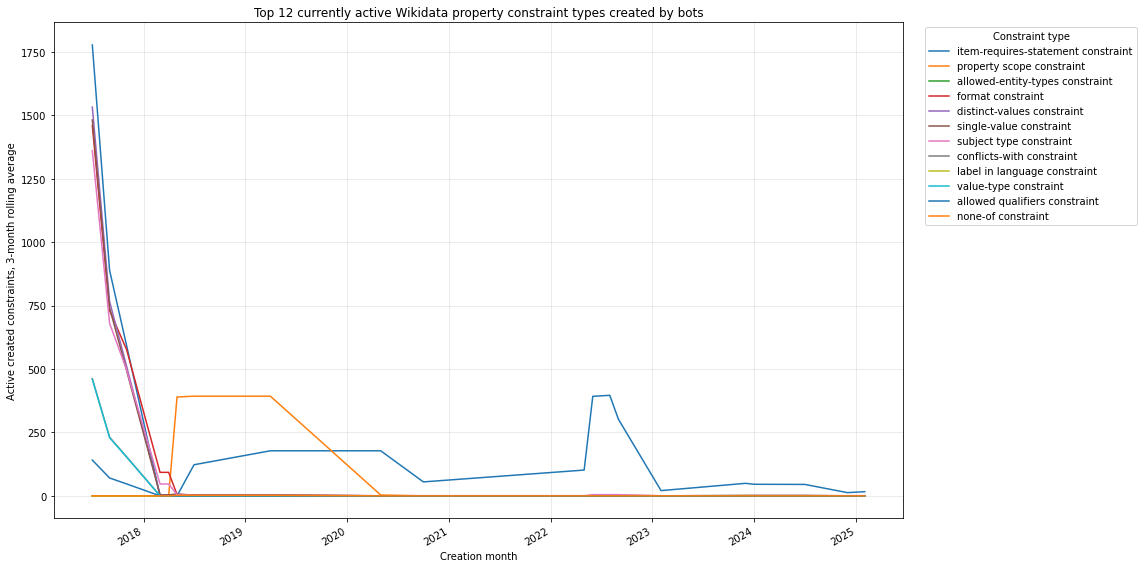

In [17]:
top_n = 12
rolling_window = 3

# Use global top labels so both charts show the same constraint types
global_top_labels = (
    df_active_created
    .groupby("constraint_label")
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

# One shared color per constraint type
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

color_map = {
    label: color_cycle[i % len(color_cycle)]
    for i, label in enumerate(global_top_labels)
}

for creator_type in ["human", "bot"]:
    temp = df_active_created.loc[
        df_active_created["creator_type"].eq(creator_type)
    ]

    monthly = (
        temp
        .groupby(["month", "constraint_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=global_top_labels, fill_value=0)
        .sort_index()
    )

    smoothed = (
        monthly
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    ax = smoothed.plot(
        kind="line",
        figsize=(16, 8),
        color=[color_map[label] for label in global_top_labels]
    )

    ax.set_title(
        f"Top {top_n} currently active Wikidata property constraint types created by {creator_type}s"
    )
    ax.set_xlabel("Creation month")
    ax.set_ylabel(
        f"Active created constraints, {rolling_window}-month rolling average"
    )

    ax.legend(
        title="Constraint type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 3.1 — Do users specialize in constraint types or target entities?

In this section, we test whether human Wikidata editors specialize in:

1. specific constraint types  
2. specific target entities, such as properties or lexemes  

A constraint statement is identified by rows where `p == "ps:P2302"`.

The subject `s` usually has the form:

- `wds:P...` for property constraints
- `wds:L...` for lexeme constraints

Before running the specialization analysis, we first check which entity types actually appear in the data.

In [18]:
import json
import re
import numpy as np
import pandas as pd

## Load curated bot list

We exclude bots from the main specialization analysis because bot activity may reflect automated maintenance rather than human specialization.

A user is considered a bot if:

- the username appears in the curated bot list
- the username starts with `bot`
- the username ends with `bot`

Matching is case-insensitive.

In [19]:
with open("wikidata_bots.json", "r", encoding="utf-8") as f:
    wikidata_bots = json.load(f)

curated_bots = {name.casefold() for name in wikidata_bots}

## Load curated constraint types

We only analyze constraint types that appear in the curated `constraint_types.json` file. These are subclasses of property constraint that used in wikidata, manually validated.

This avoids counting obsolete, malformed, experimental, or unrelated Wikidata items as constraint types.

In [20]:
with open("constraint_types.json", "r", encoding="utf-8") as f:
    constraint_types = json.load(f)

constraint_type_map = {
    "wd:" + item["cid"].rsplit("/", 1)[-1]: item["cidLabel"]
    for item in constraint_types
}

curated_constraint_qids = set(constraint_type_map)

len(curated_constraint_qids)

32

## Extract curated constraint additions

We first keep all rows that represent curated constraint additions.

At this stage, we do not yet remove bots or IP users.  
This allows us to inspect the structure of the data before filtering.

In [21]:
df_constraint_additions_all_users = df_constraints_clean.loc[
    df_constraints_clean["p"].eq("ps:P2302")
    & df_constraints_clean["o"].isin(curated_constraint_qids),
    ["s", "p", "o", "cdate", "cuser", "ddate", "duser"]
].copy()

df_constraint_additions_all_users["constraint_type"] = (
    df_constraint_additions_all_users["o"].map(constraint_type_map)
)

df_constraint_additions_all_users["cdate"] = pd.to_datetime(
    df_constraint_additions_all_users["cdate"],
    errors="coerce",
    utc=True
)

df_constraint_additions_all_users.head()

,s,p,o,cdate,cuser,ddate,duser,constraint_type
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,2016-09-24 13:47:32+00:00,Jura1,2017-07-13T04:20:20Z,KrBot,distinct-values constraint
133,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,ps:P2302,wd:Q19474404,2017-07-13 04:20:26+00:00,KrBot,2017-07-13T23:44:20Z,KrBot,single-value constraint
147,wds:P484-14C64E63-B5B0-4464-88BD-6227A8FE796F,ps:P2302,wd:Q21502404,2017-07-13 04:20:22+00:00,KrBot,2017-07-13T23:44:21Z,KrBot,format constraint
222,wds:P484-50692A14-39F2-416F-B31A-071C8D6EADA0,ps:P2302,wd:Q19474404,2017-07-13 23:44:27+00:00,KrBot,2017-07-16T17:29:37Z,KrBot,single-value constraint
269,wds:P484-BC75C143-FFAA-4998-8A62-C38DDC137E50,ps:P2302,wd:Q21502404,2017-07-13 23:44:23+00:00,KrBot,2017-07-16T17:29:38Z,KrBot,format constraint


## Sanity check: which entity prefixes appear?

The constrained entity is encoded in the statement ID.

For example:

- `wds:P10-...` refers to property `P10`
- `wds:L1371386-...` refers to lexeme `L1371386`

Here we extract the entity prefix from `s` to check whether the data contains only properties and lexemes, or anything else.

In [22]:
df_constraint_additions_all_users["raw_entity_id"] = (
    df_constraint_additions_all_users["s"]
    .str.extract(r"^wds:([A-Za-z]+\d+)-", expand=False)
)

df_constraint_additions_all_users["entity_prefix"] = (
    df_constraint_additions_all_users["raw_entity_id"]
    .str.extract(r"^([A-Za-z]+)", expand=False)
    .str.upper()
)

entity_prefix_counts = (
    df_constraint_additions_all_users["entity_prefix"]
    .value_counts(dropna=False)
    .rename_axis("entity_prefix")
    .reset_index(name="n_constraint_additions")
)

entity_prefix_counts

,entity_prefix,n_constraint_additions
0,P,80145
1,L,2


## Inspect uncaptured statement IDs

If the previous table contains missing values, we inspect examples.

This helps verify whether the regular expression is missing valid entity types or whether the rows are malformed.

In [23]:
df_constraint_additions_all_users.loc[
    df_constraint_additions_all_users["raw_entity_id"].isna(),
    ["s", "p", "o", "constraint_type", "cuser", "cdate"]
].head(20)

,s,p,o,constraint_type,cuser,cdate


## Define target entities

For this analysis, we include constraints attached to:

- properties: `P...`
- lexemes: `L...`

We call this broader dimension `target_entity`.

Rows attached to other entity types, if any, are not included in the main 3.1 test unless we explicitly decide to extend the scope.

In [24]:
df_constraint_additions_all_users["target_entity"] = (
    df_constraint_additions_all_users["s"]
    .str.extract(r"^wds:([PL]\d+)-", flags=re.IGNORECASE, expand=False)
    .str.upper()
)

df_constraint_additions_all_users["target_entity"] = (
    "wd:" + df_constraint_additions_all_users["target_entity"]
)

df_constraint_additions_all_users["target_entity_type"] = np.select(
    [
        df_constraint_additions_all_users["target_entity"].str.startswith("wd:P", na=False),
        df_constraint_additions_all_users["target_entity"].str.startswith("wd:L", na=False),
    ],
    [
        "property",
        "lexeme",
    ],
    default="other_or_uncaptured"
)

df_constraint_additions_all_users["target_entity_type"].value_counts(dropna=False)

property    80145
lexeme          2
Name: target_entity_type, dtype: int64

## Filter to human-created constraint additions

For the main specialization analysis, we keep only human-created additions.

We exclude:

- missing creators
- IP users
- bots
- rows where the target entity is not a property or lexeme

In [25]:
df_human_constraint_additions = df_constraint_additions_all_users.loc[
    df_constraint_additions_all_users["cuser"].notna()
    & ~df_constraint_additions_all_users["cuser"].apply(is_ip_address)
    & ~df_constraint_additions_all_users["cuser"].apply(is_bot)
    & df_constraint_additions_all_users["target_entity"].notna(),
    [
        "s",
        "p",
        "o",
        "constraint_type",
        "target_entity",
        "target_entity_type",
        "cdate",
        "cuser",
        "ddate",
        "duser",
    ]
].copy()

df_human_constraint_additions.head()

,s,p,o,constraint_type,target_entity,target_entity_type,cdate,cuser,ddate,duser
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,distinct-values constraint,wd:P484,property,2016-09-24 13:47:32+00:00,Jura1,2017-07-13T04:20:20Z,KrBot
395,wds:P484-3127A57A-8D36-4FF5-9483-30D641657B7F,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2022-07-09 21:27:10+00:00,Lectrician1,2022-07-09T22:00:54Z,Lectrician1
398,wds:P484-60D89EFA-AFC8-4B07-868F-41AC990A078C,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2022-07-09 21:16:02+00:00,Lectrician1,2022-07-09T22:22:05Z,Lectrician1
536,wds:P484-B0908D50-E166-4661-B397-3D479A5003C1,ps:P2302,wd:Q52004125,allowed-entity-types constraint,wd:P484,property,2020-09-30 16:26:57+00:00,Lockal,NaN,NaN
544,wds:P484-da610a56-4ad5-7352-5d34-228c33cb6f4d,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2024-10-13 09:55:48+00:00,ChristianKl,NaN,NaN


## Sanity check after filtering

We check how many human-created constraint additions remain, how many users are involved, and how many target entities are properties versus lexemes.

In [26]:
summary_3_1 = {
    "human_constraint_additions": len(df_human_constraint_additions),
    "distinct_human_creators": df_human_constraint_additions["cuser"].nunique(),
    "distinct_constraint_types": df_human_constraint_additions["constraint_type"].nunique(),
    "distinct_target_entities": df_human_constraint_additions["target_entity"].nunique(),
    "distinct_properties": df_human_constraint_additions.loc[
        df_human_constraint_additions["target_entity_type"].eq("property"),
        "target_entity"
    ].nunique(),
    "distinct_lexemes": df_human_constraint_additions.loc[
        df_human_constraint_additions["target_entity_type"].eq("lexeme"),
        "target_entity"
    ].nunique(),
}

summary_3_1

{'human_constraint_additions': 62317,
 'distinct_human_creators': 835,
 'distinct_constraint_types': 32,
 'distinct_target_entities': 9864,
 'distinct_properties': 9863,
 'distinct_lexemes': 1}

## Count user activity by constraint type

This matrix counts how many constraint additions each human user created for each constraint type.

Rows are users.  
Columns are constraint types.

In [27]:
user_by_constraint_type = (
    df_human_constraint_additions
    .groupby(["cuser", "constraint_type"])
    .size()
    .unstack(fill_value=0)
)

user_by_constraint_type.head()

constraint_type,Commons link constraint,allowed qualifiers constraint,allowed units constraint,allowed-entity-types constraint,citation-needed constraint,conflicts-with constraint,contemporary constraint,description in language constraint,difference-within-range constraint,distinct-values constraint,...,one-of qualifier value property constraint,property scope constraint,range constraint,required qualifier constraint,single-best-value constraint,single-value constraint,subject type constraint,symmetric constraint,value-requires-statement constraint,value-type constraint
cuser,,,,,,,,,,,,,,,,,,,,,
-Zest,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,1,0,0,1,0
-akko,0,0,0,8,0,0,0,0,0,9,...,0,9,0,0,0,7,7,0,0,0
.hecko,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1-Byte,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,1,0,0,0
1997kB,0,0,0,2,0,0,0,0,0,4,...,0,3,1,0,0,3,3,0,0,0


## Count user activity by target entity

This matrix counts how many constraint additions each human user created for each target entity.

Target entities include both properties and lexemes.

In [28]:
user_by_target_entity = (
    df_human_constraint_additions
    .groupby(["cuser", "target_entity"])
    .size()
    .unstack(fill_value=0)
)

user_by_target_entity.head()

target_entity,wd:L1371386,wd:P10,wd:P10000,wd:P10001,wd:P10002,wd:P10003,wd:P10004,wd:P10005,wd:P10006,wd:P10009,...,wd:P9990,wd:P9991,wd:P9992,wd:P9993,wd:P9994,wd:P9995,wd:P9996,wd:P9997,wd:P9998,wd:P9999
cuser,,,,,,,,,,,,,,,,,,,,,
-Zest,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-akko,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
.hecko,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1-Byte,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1997kB,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Calculate specialization scores

For each user, we calculate two concentration scores:

1. `constraint_type_max_share`  
   The share of the user's additions that belong to their most frequent constraint type.

2. `target_entity_max_share`  
   The share of the user's additions that belong to their most frequent target entity.

A value close to 1 means high concentration.  
A value closer to 0 means broader activity.

In [29]:
def max_share(row):
    total = row.sum()
    if total == 0:
        return np.nan
    return row.max() / total


user_specialization = pd.DataFrame({
    "total_constraint_additions": user_by_constraint_type.sum(axis=1),
    "constraint_type_max_share": user_by_constraint_type.apply(max_share, axis=1),
    "target_entity_max_share": user_by_target_entity.apply(max_share, axis=1),
})

user_specialization["dominant_constraint_type"] = user_by_constraint_type.idxmax(axis=1)
user_specialization["dominant_target_entity"] = user_by_target_entity.idxmax(axis=1)

user_specialization.head()

,total_constraint_additions,constraint_type_max_share,target_entity_max_share,dominant_constraint_type,dominant_target_entity
cuser,,,,,
-Zest,7,0.285714,0.428571,distinct-values constraint,wd:P5020
-akko,55,0.163636,0.145455,distinct-values constraint,wd:P8923
.hecko,3,0.333333,1.000000,allowed-entity-types constraint,wd:P13326
1-Byte,7,0.428571,0.857143,item-requires-statement constraint,wd:P4528
1997kB,18,0.222222,0.277778,distinct-values constraint,wd:P9076


## Classify users by specialization pattern

We use a simple and interpretable threshold-based classification.

A user is classified as:

- `constraint-type specialist` if at least 70% of their additions are in one constraint type
- `target-entity specialist` if at least 70% of their additions are on one property or lexeme
- `dual specialist` if both conditions hold
- `generalist` otherwise

This threshold is exploratory, so we later test the robustness of the result across different minimum activity thresholds.

In [30]:
type_threshold = 0.70
target_entity_threshold = 0.70

conditions = [
    (user_specialization["constraint_type_max_share"] >= type_threshold)
    & (user_specialization["target_entity_max_share"] >= target_entity_threshold),

    (user_specialization["constraint_type_max_share"] >= type_threshold)
    & (user_specialization["target_entity_max_share"] < target_entity_threshold),

    (user_specialization["constraint_type_max_share"] < type_threshold)
    & (user_specialization["target_entity_max_share"] >= target_entity_threshold),
]

choices = [
    "dual specialist",
    "constraint-type specialist",
    "target-entity specialist",
]

user_specialization["specialization_class"] = np.select(
    conditions,
    choices,
    default="generalist"
)

user_specialization["specialization_class"].value_counts()

generalist                    355
dual specialist               302
target-entity specialist      100
constraint-type specialist     78
Name: specialization_class, dtype: int64

## Activity distribution

Before choosing a minimum activity threshold, we inspect how many constraint additions users created.

This is important because users with very few additions can appear specialized mechanically.
For example, a user with only one addition has a maximum-share score of 1.0 by definition.

In [31]:
user_specialization["total_constraint_additions"].describe()

count     835.000000
mean       74.631138
std       452.645888
min         1.000000
25%         1.000000
50%         3.000000
75%        12.000000
max      7927.000000
Name: total_constraint_additions, dtype: float64

## Sensitivity analysis for minimum activity threshold

Because low-activity users can appear artificially specialized, we do not rely on a single arbitrary cutoff.

Instead, we evaluate the classification across several minimum activity thresholds.

In [32]:
thresholds = [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

sensitivity_results_3_1 = []

for min_additions in thresholds:
    temp = user_specialization.loc[
        user_specialization["total_constraint_additions"] >= min_additions
    ].copy()

    counts = temp["specialization_class"].value_counts()

    row = {
        "min_additions": min_additions,
        "n_users": len(temp),
        "generalist": counts.get("generalist", 0),
        "constraint_type_specialist": counts.get("constraint-type specialist", 0),
        "target_entity_specialist": counts.get("target-entity specialist", 0),
        "dual_specialist": counts.get("dual specialist", 0),
    }

    sensitivity_results_3_1.append(row)

sensitivity_results_3_1 = pd.DataFrame(sensitivity_results_3_1)

for col in [
    "generalist",
    "constraint_type_specialist",
    "target_entity_specialist",
    "dual_specialist",
]:
    sensitivity_results_3_1[col + "_share"] = (
        sensitivity_results_3_1[col] / sensitivity_results_3_1["n_users"]
    )

sensitivity_results_3_1

,min_additions,n_users,generalist,constraint_type_specialist,target_entity_specialist,dual_specialist,generalist_share,constraint_type_specialist_share,target_entity_specialist_share,dual_specialist_share
0,1,835,355,78,100,302,0.425150,0.093413,0.119760,0.361677
1,2,567,355,78,100,34,0.626102,0.137566,0.176367,0.059965
2,5,338,272,36,25,5,0.804734,0.106509,0.073964,0.014793
3,10,235,208,20,6,1,0.885106,0.085106,0.025532,0.004255
4,15,189,172,14,2,1,0.910053,0.074074,0.010582,0.005291
5,20,163,150,12,1,0,0.920245,0.073620,0.006135,0.000000
6,25,141,132,8,1,0,0.936170,0.056738,0.007092,0.000000
7,30,128,119,8,1,0,0.929688,0.062500,0.007812,0.000000
8,35,124,115,8,1,0,0.927419,0.064516,0.008065,0.000000
9,40,118,110,7,1,0,0.932203,0.059322,0.008475,0.000000


## Main descriptive threshold: at least 20 additions

For the main descriptive table, we use a conservative threshold of at least 20 constraint additions.

This threshold is not treated as the only valid cutoff.  
It is interpreted together with the sensitivity analysis above.

In [33]:
min_additions = 20

user_specialization_20 = user_specialization.loc[
    user_specialization["total_constraint_additions"] >= min_additions
].copy()

user_specialization_20["specialization_class"].value_counts()

generalist                    150
constraint-type specialist     12
target-entity specialist        1
Name: specialization_class, dtype: int64

## Inspect recurring specialists

This table shows users with at least 20 constraint additions who are classified as specialists.

In [34]:
user_specialization_20.loc[
    user_specialization_20["specialization_class"] != "generalist"
].sort_values(
    ["specialization_class", "total_constraint_additions"],
    ascending=[True, False]
)

,total_constraint_additions,constraint_type_max_share,target_entity_max_share,dominant_constraint_type,dominant_target_entity,specialization_class
cuser,,,,,,
Lectrician1,609,0.865353,0.011494,property scope constraint,wd:P11127,constraint-type specialist
Abián,275,0.818182,0.029091,contemporary constraint,wd:P7006,constraint-type specialist
ChristianKl,266,0.774436,0.018797,property scope constraint,wd:P927,constraint-type specialist
Sabelöga,119,0.857143,0.201681,label in language constraint,wd:P5437,constraint-type specialist
Mitte27,111,0.819820,0.063063,label in language constraint,wd:P13304,constraint-type specialist
UV,97,0.783505,0.123711,item-requires-statement constraint,wd:P8430,constraint-type specialist
RVA2869,53,0.773585,0.113208,label in language constraint,wd:P1782,constraint-type specialist
Kethyga,37,0.729730,0.108108,allowed qualifiers constraint,wd:P210,constraint-type specialist
Romulanus,22,0.772727,0.181818,item-requires-statement constraint,wd:P2359,constraint-type specialist


## Inspect highest-volume users

This table checks whether the largest human constraint creators are specialists or generalists.

In [35]:
user_specialization_20.sort_values(
    "total_constraint_additions",
    ascending=False
).head(20)

,total_constraint_additions,constraint_type_max_share,target_entity_max_share,dominant_constraint_type,dominant_target_entity,specialization_class
cuser,,,,,,
Lockal,7927,0.565536,0.000883,allowed-entity-types constraint,wd:P3192,generalist
Pintoch,5498,0.278283,0.001091,distinct-values constraint,wd:P4861,generalist
Pamputt,4621,0.157758,0.003030,format constraint,wd:P9046,generalist
Trade,3438,0.317336,0.019779,item-requires-statement constraint,wd:P31,generalist
Jura1,3067,0.459081,0.025106,distinct-values constraint,wd:P5086,generalist
Manu1400,3046,0.467498,0.002626,item-requires-statement constraint,wd:P5242,generalist
Kirilloparma,2679,0.157895,0.010452,property scope constraint,wd:P369,generalist
Thierry Caro,2559,0.252442,0.004299,single-value constraint,wd:P8924,generalist
AdamSeattle,2277,0.179622,0.004831,property scope constraint,wd:P13093,generalist


## Interpretation guide

This analysis answers whether recurring human constraint creators concentrate their work by:

- constraint type
- target entity, including properties and lexemes

If specialization among recurring users is mostly constraint-type specialization, this suggests that some editors develop expertise in particular constraint mechanisms.

If target-entity specialization is rare among recurring users, this suggests that sustained constraint creation is less often centered on a single property or lexeme.

### Interpretation

The results suggest that apparent specialization is strongly affected by user activity volume. When all users are included, many editors appear to be target-entity or dual specialists, but this is largely explained by sparse activity: users with one or two additions can have perfect concentration scores by construction.

After applying minimum activity thresholds, the distribution stabilizes. Among users with at least 20 human-created constraint additions, 149 of 162 users are classified as generalists, 12 as constraint-type specialists, and only 1 as a target-entity specialist. No dual specialists remain.

This indicates that sustained human constraint creation is usually broad rather than narrowly concentrated. When specialization does appear among recurring contributors, it is more often organized around constraint types than around individual target entities.

Although the method includes both properties and lexemes as target entities, lexeme constraints are empirically negligible in this dataset, with only two curated constraint additions attached to lexemes. Therefore, target-entity specialization is driven almost entirely by property-level activity.

## Final summary table for RQ 3.1

This table summarizes specialization patterns among recurring human constraint creators (minimum 20 additions).

In [36]:
specialization_summary_3_1 = (
    user_specialization_20["specialization_class"]
    .value_counts()
    .rename_axis("specialization_class")
    .reset_index(name="n_users")
)

specialization_summary_3_1["share"] = (
    specialization_summary_3_1["n_users"]
    / specialization_summary_3_1["n_users"].sum()
)

specialization_summary_3_1

,specialization_class,n_users,share
0,generalist,150,0.920245
1,constraint-type specialist,12,0.073620
2,target-entity specialist,1,0.006135


## Specialization sensitivity across activity thresholds

This figure shows how specialization classes change as the minimum activity threshold increases.

It helps demonstrate that the main conclusion is robust and not driven by low-activity users.

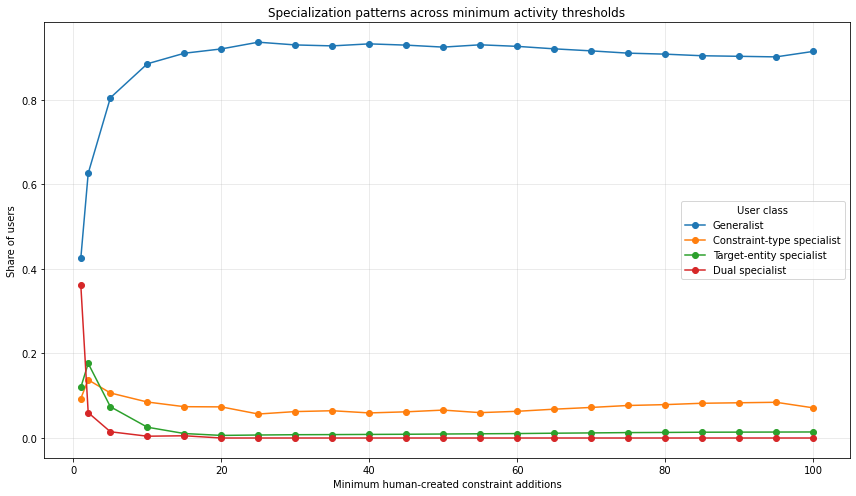

In [37]:
plot_cols = [
    "generalist_share",
    "constraint_type_specialist_share",
    "target_entity_specialist_share",
    "dual_specialist_share",
]

ax = sensitivity_results_3_1.set_index("min_additions")[plot_cols].plot(
    kind="line",
    figsize=(12, 7),
    marker="o"
)

ax.set_title("Specialization patterns across minimum activity thresholds")
ax.set_xlabel("Minimum human-created constraint additions")
ax.set_ylabel("Share of users")

ax.legend(
    [
        "Generalist",
        "Constraint-type specialist",
        "Target-entity specialist",
        "Dual specialist"
    ],
    title="User class"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3.2 — How many users participate in a constraint lifecycle?

In 3.1, we focused on who creates constraints.

Now we move from creation behavior to the full lifecycle of a constraint.

A constraint statement is identified by its statement ID:

`wds:P...` or `wds:L...`

Its lifecycle includes:

- initial creation (`ps:P2302`)
- qualifier additions and modifications (`pq:*`)
- rank changes (`wikibase:rank`)
- eventual deletion (`ddate`, `duser`)

The goal of this section is to estimate how collaborative constraint maintenance is.

We ask:

> How many distinct human users typically participate in the lifecycle of a single constraint statement?

This helps distinguish between:

- single-editor constraints
- creator + maintainer constraints
- collaboratively refined constraints
- high-churn constraints involving many editors

In [38]:
import pandas as pd
import numpy as np

## Step 1 — Identify valid curated constraint statements

We first identify valid constraint statements using rows where:

- `p == "ps:P2302"`
- `o` is a curated constraint type

These rows define the set of constraint statement IDs (`s`) whose lifecycle we will follow.

In [39]:
valid_constraint_statements = set(
    df_constraints_clean.loc[
        df_constraints_clean["p"].eq("ps:P2302")
        & df_constraints_clean["o"].isin(curated_constraint_qids),
        "s"
    ]
)

len(valid_constraint_statements)

77277

## Step 2 — Keep all rows belonging to those statements

Now we keep every row whose subject `s` belongs to one of these valid constraint statements.

This includes:

- the original constraint creation row (`ps:P2302`)
- qualifier rows (`pq:*`)
- rank rows
- later edits attached to the same statement

In [40]:
df_constraint_lifecycle = df_constraints_clean.loc[
    df_constraints_clean["s"].isin(valid_constraint_statements)
].copy()

df_constraint_lifecycle.head()

,s,p,o,cdate,cuser,ddate,duser
74,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,wikibase:rank,wikibase:NormalRank,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
76,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3817441,2017-07-13T04:20:45Z,KrBot,2017-07-13T23:44:20Z,KrBot
77,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3680919,2017-07-13T04:20:46Z,KrBot,2017-07-13T23:44:20Z,KrBot
78,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q11295066,2017-07-13T04:20:55Z,KrBot,2017-07-13T23:44:20Z,KrBot


## Step 3 — Sanity check: what kinds of lifecycle rows exist?

Before filtering users, we inspect which predicates occur inside constraint lifecycles.

This helps verify that qualifier rows and maintenance rows are actually being captured.

In [41]:
(
    df_constraint_lifecycle["p"]
    .value_counts()
    .head(30)
)

ps:P2302         82888
wikibase:rank    79375
pq:P2303         42515
pq:P2305         38894
pq:P2306         29149
pq:P2308         27740
pq:P2316         19899
pq:P5314         17543
pq:P1793         16287
pq:P2309         10649
pq:P4680          5870
pq:P4155          2558
pq:P6607          1834
pq:P424           1799
pq:P2916          1113
pq:P9729           796
pq:P2312           753
pq:P2313           639
pq:P6824           636
pq:P2304           311
pq:P2241           258
pq:P2307           130
pq:P31             108
pq:P2559            94
pq:P1687            82
pq:P2311            77
pq:P6104            75
pq:P2310            54
pq:P5328            45
pq:P5323            39
Name: p, dtype: int64

## Step 4 — Focus on human participants

For this research question, we focus on human collaborative participation.

We exclude:

- missing users
- IP editors
- bots

This allows us to estimate how many named human editors participate in each lifecycle.

In [42]:
mask_valid_human_user = (
    df_constraint_lifecycle["cuser"].notna()
    & ~df_constraint_lifecycle["cuser"].apply(is_ip_address)
    & ~df_constraint_lifecycle["cuser"].apply(is_bot)
)

df_constraint_lifecycle_humans = df_constraint_lifecycle.loc[
    mask_valid_human_user
].copy()

len(df_constraint_lifecycle_humans)

287301

## Step 5 — Count distinct human users per constraint statement

For each constraint statement (`s`), we count:

> How many distinct human users added rows during its lifecycle?

This is our first measure of collaborative participation.

In [43]:
users_per_constraint = (
    df_constraint_lifecycle_humans
    .groupby("s")["cuser"]
    .nunique()
    .rename("n_human_users")
    .reset_index()
)

users_per_constraint.head()

,s,n_human_users
0,wds:L1371386-419bce64-4e7b-117b-3eee-6f9dfd27a6f5,1
1,wds:L1371386-59f3cc5d-44f4-f113-2cd5-522e303cb9be,1
2,wds:P10-1529A843-91A8-4FEA-B43F-9A3258446A38,7
3,wds:P10-7078A980-32E7-4103-B102-B8F9DFB507E8,3
4,wds:P10-c6043ffd-45c6-add1-344d-f60fb046d83e,1


## Step 6 — Add metadata for interpretation

We also attach:

- constraint type
- target entity (property or lexeme)
- deletion status

This helps compare collaboration across different kinds of constraints.

In [44]:
constraint_metadata = (
    df_constraints_clean.loc[
        df_constraints_clean["p"].eq("ps:P2302")
        & df_constraints_clean["o"].isin(curated_constraint_qids),
        ["s", "o", "ddate"]
    ]
    .copy()
)

constraint_metadata["constraint_type"] = (
    constraint_metadata["o"].map(constraint_type_map)
)

constraint_metadata["target_entity"] = (
    constraint_metadata["s"]
    .str.extract(r"^wds:([PL]\d+)-", expand=False)
    .str.upper()
)

constraint_metadata["target_entity"] = (
    "wd:" + constraint_metadata["target_entity"]
)

constraint_metadata["target_entity_type"] = np.select(
    [
        constraint_metadata["target_entity"].str.startswith("wd:P", na=False),
        constraint_metadata["target_entity"].str.startswith("wd:L", na=False),
    ],
    [
        "property",
        "lexeme",
    ],
    default="other_or_uncaptured"
)

constraint_metadata["is_deleted"] = (
    constraint_metadata["ddate"].notna()
)

constraint_metadata = constraint_metadata[
    [
        "s",
        "constraint_type",
        "target_entity",
        "target_entity_type",
        "is_deleted",
    ]
]

constraint_metadata.head()

,s,constraint_type,target_entity,target_entity_type,is_deleted
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,distinct-values constraint,wd:P484,property,True
133,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,single-value constraint,wd:P484,property,True
147,wds:P484-14C64E63-B5B0-4464-88BD-6227A8FE796F,format constraint,wd:P484,property,True
222,wds:P484-50692A14-39F2-416F-B31A-071C8D6EADA0,single-value constraint,wd:P484,property,True
269,wds:P484-BC75C143-FFAA-4998-8A62-C38DDC137E50,format constraint,wd:P484,property,True


## Step 7 — Merge participation counts with metadata

In [45]:
constraint_participation = users_per_constraint.merge(
    constraint_metadata,
    on="s",
    how="left"
)

constraint_participation.head()

,s,n_human_users,constraint_type,target_entity,target_entity_type,is_deleted
0,wds:L1371386-419bce64-4e7b-117b-3eee-6f9dfd27a6f5,1,symmetric constraint,wd:L1371386,lexeme,True
1,wds:L1371386-59f3cc5d-44f4-f113-2cd5-522e303cb9be,1,symmetric constraint,wd:L1371386,lexeme,False
2,wds:P10-1529A843-91A8-4FEA-B43F-9A3258446A38,7,format constraint,wd:P10,property,False
3,wds:P10-7078A980-32E7-4103-B102-B8F9DFB507E8,3,allowed qualifiers constraint,wd:P10,property,False
4,wds:P10-c6043ffd-45c6-add1-344d-f60fb046d83e,1,property scope constraint,wd:P10,property,False


## Step 8 — Basic descriptive statistics

We inspect:

- average number of human users per constraint
- median participation
- maximum observed participation

This gives a first overview of lifecycle collaboration.

In [46]:
constraint_participation["n_human_users"].describe()

count    69477.000000
mean         1.464312
std          1.837287
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         56.000000
Name: n_human_users, dtype: float64

## Step 9 — Distribution of participation levels

This helps classify lifecycle types:

- 1 user → single-editor constraint
- 2 users → creator + maintainer
- 3+ users → collaborative refinement
- many users → high-churn collaborative constraints

In [47]:
constraint_participation["n_human_users"].value_counts().sort_index().head(30)

1     55006
2      9347
3      2527
4       881
5       444
6       280
7       186
8       130
9       109
10       78
11       78
12       52
13       45
14       52
15       39
16       20
17       22
18       24
19       13
20       14
21       13
22       13
23       11
24        8
25        9
26        6
27        4
28        2
29        3
30       16
Name: n_human_users, dtype: int64

## Step 10 — Compare deleted vs non-deleted constraints

Do deleted constraints involve more users?

This helps distinguish stable constraints from collaboratively revised or contested ones.

In [48]:
constraint_participation.groupby("is_deleted")["n_human_users"].describe()

,count,mean,std,min,25%,50%,75%,max
is_deleted,,,,,,,,
False,59460.0,1.406424,1.582823,1.0,1.0,1.0,1.0,56.0
True,10017.0,1.807927,2.899034,1.0,1.0,1.0,1.0,51.0


## Step 11 — Compare by constraint type

Some constraint types may require more collaborative refinement than others.

For example:

- `format constraint` may stabilize quickly
- `item-requires-statement constraint` may involve more negotiation and qualifier updates

In [49]:
(
    constraint_participation
    .groupby("constraint_type")["n_human_users"]
    .describe()
    .sort_values("mean", ascending=False)
    .head(20)
)

,count,mean,std,min,25%,50%,75%,max
constraint_type,,,,,,,,
allowed qualifiers constraint,1022.0,4.817025,6.962526,1.0,1.0,2.0,5.0,50.0
one-of constraint,296.0,4.645270,7.717854,1.0,1.0,2.0,5.0,56.0
value-type constraint,1072.0,3.320896,4.189223,1.0,1.0,2.0,4.0,36.0
allowed units constraint,442.0,2.785068,5.123106,1.0,1.0,1.0,2.0,47.0
Commons link constraint,69.0,2.608696,4.232985,1.0,1.0,1.0,1.0,15.0
symmetric constraint,54.0,2.370370,2.217395,1.0,1.0,1.0,3.0,7.0
value-requires-statement constraint,547.0,2.349177,3.752974,1.0,1.0,1.0,3.0,43.0
lexeme-value-requires-lexical-category constraint,3.0,2.333333,0.577350,2.0,2.0,2.0,2.5,3.0
single-best-value constraint,303.0,2.267327,3.309302,1.0,1.0,1.0,2.0,30.0


## Step 12 — Final summary table

We summarize the share of:

- single-editor constraints
- two-user constraints
- collaborative constraints involving 3 or more users

In [50]:
constraint_participation["lifecycle_class"] = np.select(
    [
        constraint_participation["n_human_users"] == 1,
        constraint_participation["n_human_users"] == 2,
        constraint_participation["n_human_users"] >= 3,
    ],
    [
        "single-editor",
        "two-user",
        "collaborative (3+ users)",
    ],
    default="other"
)

lifecycle_summary = (
    constraint_participation["lifecycle_class"]
    .value_counts()
    .rename_axis("lifecycle_class")
    .reset_index(name="n_constraints")
)

lifecycle_summary["share"] = (
    lifecycle_summary["n_constraints"]
    / lifecycle_summary["n_constraints"].sum()
)

lifecycle_summary

,lifecycle_class,n_constraints,share
0,single-editor,55006,0.791715
1,two-user,9347,0.134534
2,collaborative (3+ users),5124,0.073751


## Interpretation target

This analysis answers:

> Is a Wikidata constraint usually created and maintained by one editor, or does it become a collaborative object involving multiple users?

The key outputs are:

- the typical number of human participants per constraint
- the share of single-editor vs collaborative constraints
- whether deleted constraints involve more users
- which constraint types show the highest collaborative participation

## Robustness check: constraints with no human lifecycle participants

The previous analysis counts constraints with at least one human participant.  
We now check how many curated constraint statements have no human-created lifecycle rows after removing bots, IPs, and missing users.

In [51]:
all_constraint_participation = pd.DataFrame({
    "s": list(valid_constraint_statements)
})

all_constraint_participation = all_constraint_participation.merge(
    users_per_constraint,
    on="s",
    how="left"
)

all_constraint_participation["n_human_users"] = (
    all_constraint_participation["n_human_users"]
    .fillna(0)
    .astype(int)
)

all_constraint_participation["n_human_users"].value_counts().sort_index().head(10)

0    10449
1    54106
2     8594
3     2173
4      715
5      352
6      213
7      128
8       93
9       71
Name: n_human_users, dtype: int64

## Lifecycle participation including zero-human cases

The previous table counted only constraints with at least one human lifecycle participant.

After merging back to all curated constraint statements, we find that some constraints have zero observed human participants after removing bots, IP users, and missing users.

These constraints are not necessarily unedited; rather, they have no lifecycle rows attributed to named human users under our filtering rules.

In [52]:
lifecycle_summary_all = (
    all_constraint_participation["n_human_users"]
    .value_counts()
    .sort_index()
    .rename_axis("n_human_users")
    .reset_index(name="n_constraints")
)

lifecycle_summary_all["share"] = (
    lifecycle_summary_all["n_constraints"]
    / lifecycle_summary_all["n_constraints"].sum()
)

lifecycle_summary_all.head(20)

,n_human_users,n_constraints,share
0,0,10449,0.135215
1,1,54106,0.700157
2,2,8594,0.111210
3,3,2173,0.028120
4,4,715,0.009252
5,5,352,0.004555
6,6,213,0.002756
7,7,128,0.001656
8,8,93,0.001203
9,9,71,0.000919


## Compact lifecycle participation summary

For readability, we summarize the full distribution into:

- zero-human
- single-human
- two-human
- multi-human, meaning three or more named human users

In [53]:
all_constraint_participation["lifecycle_class"] = np.select(
    [
        all_constraint_participation["n_human_users"] == 0,
        all_constraint_participation["n_human_users"] == 1,
        all_constraint_participation["n_human_users"] == 2,
        all_constraint_participation["n_human_users"] >= 3,
    ],
    [
        "zero-human",
        "single-human",
        "two-human",
        "multi-human (3+)",
    ],
    default="other"
)

lifecycle_summary_all_compact = (
    all_constraint_participation["lifecycle_class"]
    .value_counts()
    .rename_axis("lifecycle_class")
    .reset_index(name="n_constraints")
)

lifecycle_summary_all_compact["share"] = (
    lifecycle_summary_all_compact["n_constraints"]
    / lifecycle_summary_all_compact["n_constraints"].sum()
)

lifecycle_summary_all_compact

,lifecycle_class,n_constraints,share
0,single-human,54106,0.700157
1,zero-human,10449,0.135215
2,two-human,8594,0.111210
3,multi-human (3+),4128,0.053418


## 3.2a — User roles in constraint lifecycles

Lifecycle participation can involve different kinds of work.

Here we distinguish between:

- constraint creation: rows where `p == "ps:P2302"`
- qualifier maintenance: rows where `p` starts with `pq:`
- rank maintenance: rows where `p == "wikibase:rank"`

This lets us ask whether some users mainly create constraints, while others mainly maintain or refine the qualifiers that define how constraints are tested.

In [54]:
df_constraint_lifecycle_humans["lifecycle_action_type"] = np.select(
    [
        df_constraint_lifecycle_humans["p"].eq("ps:P2302"),
        df_constraint_lifecycle_humans["p"].str.startswith("pq:", na=False),
        df_constraint_lifecycle_humans["p"].eq("wikibase:rank"),
    ],
    [
        "constraint_creation",
        "qualifier_maintenance",
        "rank_maintenance",
    ],
    default="other"
)

df_constraint_lifecycle_humans["lifecycle_action_type"].value_counts()

qualifier_maintenance    162416
constraint_creation       62501
rank_maintenance          62384
Name: lifecycle_action_type, dtype: int64

## Count lifecycle action types by user

For each human user, we count how many lifecycle rows they added in each action category.

In [55]:
user_lifecycle_roles = (
    df_constraint_lifecycle_humans
    .groupby(["cuser", "lifecycle_action_type"])
    .size()
    .unstack(fill_value=0)
)

for col in ["constraint_creation", "qualifier_maintenance", "rank_maintenance", "other"]:
    if col not in user_lifecycle_roles.columns:
        user_lifecycle_roles[col] = 0

user_lifecycle_roles["total_lifecycle_actions"] = user_lifecycle_roles.sum(axis=1)

user_lifecycle_roles["creation_share"] = (
    user_lifecycle_roles["constraint_creation"]
    / user_lifecycle_roles["total_lifecycle_actions"]
)

user_lifecycle_roles["qualifier_share"] = (
    user_lifecycle_roles["qualifier_maintenance"]
    / user_lifecycle_roles["total_lifecycle_actions"]
)

user_lifecycle_roles["rank_share"] = (
    user_lifecycle_roles["rank_maintenance"]
    / user_lifecycle_roles["total_lifecycle_actions"]
)

user_lifecycle_roles.head()

lifecycle_action_type,constraint_creation,qualifier_maintenance,rank_maintenance,other,total_lifecycle_actions,creation_share,qualifier_share,rank_share
cuser,,,,,,,,
&beer&love,0,1,0,0,1,0.000000,1.000000,0.000000
(Oinkers42),0,1,1,0,2,0.000000,0.500000,0.500000
-Zest,7,49,7,0,63,0.111111,0.777778,0.111111
-akko,55,70,55,0,180,0.305556,0.388889,0.305556
.hecko,3,9,4,0,16,0.187500,0.562500,0.250000


## Classify lifecycle roles

To avoid over-interpreting one-off users, we classify roles among users with at least 20 lifecycle actions.

As before, the threshold is used for descriptive presentation only; the distribution of role shares can also be inspected directly.

In [56]:
min_lifecycle_actions = 20

user_lifecycle_roles_20 = user_lifecycle_roles.loc[
    user_lifecycle_roles["total_lifecycle_actions"] >= min_lifecycle_actions
].copy()

role_threshold = 0.70

conditions = [
    user_lifecycle_roles_20["creation_share"] >= role_threshold,
    user_lifecycle_roles_20["qualifier_share"] >= role_threshold,
    user_lifecycle_roles_20["rank_share"] >= role_threshold,
]

choices = [
    "creation-focused",
    "qualifier-focused",
    "rank-focused",
]

user_lifecycle_roles_20["lifecycle_role"] = np.select(
    conditions,
    choices,
    default="mixed"
)

user_lifecycle_roles_20["lifecycle_role"].value_counts()

qualifier-focused    300
mixed                217
Name: lifecycle_role, dtype: int64

## Inspect strongest creation-focused and qualifier-focused users

This table helps identify whether lifecycle work is divided between users who create constraints and users who refine their qualifier definitions.

In [57]:
user_lifecycle_roles_20.sort_values(
    ["lifecycle_role", "total_lifecycle_actions"],
    ascending=[True, False]
).head(50)

lifecycle_action_type,constraint_creation,qualifier_maintenance,rank_maintenance,other,total_lifecycle_actions,creation_share,qualifier_share,rank_share,lifecycle_role
cuser,,,,,,,,,
Lockal,7927,11881,7938,0,27746,0.285699,0.428206,0.286095,mixed
Trade,3439,13481,3391,0,20311,0.169317,0.663729,0.166954,mixed
Manu1400,3048,9939,3031,0,16018,0.190286,0.620489,0.189225,mixed
Pintoch,5507,3851,5499,0,14857,0.370667,0.259204,0.370129,mixed
Pamputt,4621,5258,4622,0,14501,0.318668,0.362596,0.318737,mixed
AdamSeattle,2277,6497,2276,0,11050,0.206063,0.587964,0.205973,mixed
Jura1,3119,4711,3111,0,10941,0.285074,0.430582,0.284343,mixed
Kirilloparma,2679,3806,2692,0,9177,0.291925,0.414732,0.293342,mixed
Thierry Caro,2559,2488,2556,0,7603,0.336578,0.327239,0.336183,mixed


## Interpretation guide

This analysis distinguishes lifecycle participation roles.

A user with a high creation share mainly introduces new constraints.

A user with a high qualifier share mainly contributes to the operational definition of constraints by adding or modifying qualifier rows.

If many high-activity users are qualifier-focused, this suggests that constraint governance is not only about creating constraints, but also about maintaining and refining how constraints are tested.

In [58]:
lifecycle_summary_all_compact

,lifecycle_class,n_constraints,share
0,single-human,54106,0.700157
1,zero-human,10449,0.135215
2,two-human,8594,0.111210
3,multi-human (3+),4128,0.053418


In [59]:
constraint_participation.groupby("is_deleted")["n_human_users"].describe()

,count,mean,std,min,25%,50%,75%,max
is_deleted,,,,,,,,
False,59460.0,1.406424,1.582823,1.0,1.0,1.0,1.0,56.0
True,10017.0,1.807927,2.899034,1.0,1.0,1.0,1.0,51.0


In [60]:
constraint_participation.groupby("is_deleted")["n_human_users"].median()

is_deleted
False    1.0
True     1.0
Name: n_human_users, dtype: float64

### Interpretation

Most constraint lifecycles are minimally collaborative in terms of named human participation.

Across all curated constraint statements, 70.0% involve exactly one named human user, while 13.6% have no named human participant after excluding bots, IP users, and missing users. Another 11.1% involve two human users, and only 5.3% involve three or more human users.

This suggests that most constraint lifecycles are not broadly collaborative. They are usually either single-human lifecycles or lifecycles with no observed human participation under our filtering rules.

Deleted constraints involve somewhat more human users on average than non-deleted constraints, with a mean of 1.81 compared to 1.41. However, the median is 1 in both groups, indicating that even deleted constraints are usually not broadly collaborative.

In [61]:
user_lifecycle_roles_20["lifecycle_role"].value_counts()

qualifier-focused    300
mixed                217
Name: lifecycle_role, dtype: int64

In [62]:
user_lifecycle_roles_20.sort_values(
    ["qualifier_share", "qualifier_maintenance"],
    ascending=[False, False]
).head(30)

lifecycle_action_type,constraint_creation,qualifier_maintenance,rank_maintenance,other,total_lifecycle_actions,creation_share,qualifier_share,rank_share,lifecycle_role
cuser,,,,,,,,,
StarTrekker,0,213,0,0,213,0.0,1.0,0.0,qualifier-focused
Una tantum,0,155,0,0,155,0.0,1.0,0.0,qualifier-focused
Ｈ00000000000,0,151,0,0,151,0.0,1.0,0.0,qualifier-focused
Ipoellet,0,146,0,0,146,0.0,1.0,0.0,qualifier-focused
Mith,0,127,0,0,127,0.0,1.0,0.0,qualifier-focused
Blz 2049,0,104,0,0,104,0.0,1.0,0.0,qualifier-focused
YANN92340,0,104,0,0,104,0.0,1.0,0.0,qualifier-focused
Justus Nussbaum,0,79,0,0,79,0.0,1.0,0.0,qualifier-focused
Osteologia,0,72,0,0,72,0.0,1.0,0.0,qualifier-focused


## Interpretation of lifecycle roles

A notable pattern emerges when distinguishing between constraint creation and qualifier maintenance.

Among users with at least 20 lifecycle actions, no users are classified as creation-focused, while 299 are qualifier-focused and 217 are mixed contributors.

Many high-activity users contribute exclusively through qualifier rows (`pq:*`) and never through the initial constraint creation row (`ps:P2302`). This indicates that a substantial part of constraint governance happens after creation, through the maintenance of qualifiers that define how constraints are tested.

This result should be interpreted with care because each constraint statement has only one creation row (`ps:P2302`) but may accumulate many qualifier rows over time. Qualifier maintenance therefore generates more observable lifecycle actions by design. Nevertheless, the result shows that many recurring participants are maintainers rather than creators, and that creator and maintainer roles are often separated.

In [63]:
user_lifecycle_roles_20.sort_values(
    ["creation_share", "constraint_creation"],
    ascending=[False, False]
).head(30)

lifecycle_action_type,constraint_creation,qualifier_maintenance,rank_maintenance,other,total_lifecycle_actions,creation_share,qualifier_share,rank_share,lifecycle_role
cuser,,,,,,,,,
Mikey641,18,3,17,0,38,0.473684,0.078947,0.447368,mixed
Abián,275,94,275,0,644,0.427019,0.145963,0.427019,mixed
Visite fortuitement prolongée,15,7,15,0,37,0.405405,0.189189,0.405405,mixed
Vennor,9,5,9,0,23,0.391304,0.217391,0.391304,mixed
Pintoch,5507,3851,5499,0,14857,0.370667,0.259204,0.370129,mixed
Martin Urbanec,22,18,22,0,62,0.354839,0.290323,0.354839,mixed
Yaron Koren,8,7,8,0,23,0.347826,0.304348,0.347826,mixed
MasterRus21thCentury,249,227,247,0,723,0.344398,0.313970,0.341632,mixed
Lectrician1,609,554,609,0,1772,0.343679,0.312641,0.343679,mixed


## Sensitivity analysis for lifecycle-role classification

The role classification above uses two descriptive choices:

- minimum 20 lifecycle actions
- 70% share to classify a user as focused on one action type

To avoid relying on a single arbitrary cutoff, we test whether the role pattern is stable across multiple minimum activity thresholds.

We keep the 70% focus threshold fixed for interpretability and vary the minimum number of lifecycle actions.

In [64]:
lifecycle_thresholds = [1, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

role_sensitivity_results = []

for min_actions in lifecycle_thresholds:
    temp = user_lifecycle_roles.loc[
        user_lifecycle_roles["total_lifecycle_actions"] >= min_actions
    ].copy()

    conditions = [
        temp["creation_share"] >= role_threshold,
        temp["qualifier_share"] >= role_threshold,
        temp["rank_share"] >= role_threshold,
    ]

    choices = [
        "creation-focused",
        "qualifier-focused",
        "rank-focused",
    ]

    temp["lifecycle_role"] = np.select(
        conditions,
        choices,
        default="mixed"
    )

    counts = temp["lifecycle_role"].value_counts()

    role_sensitivity_results.append({
        "min_lifecycle_actions": min_actions,
        "n_users": len(temp),
        "creation_focused": counts.get("creation-focused", 0),
        "qualifier_focused": counts.get("qualifier-focused", 0),
        "rank_focused": counts.get("rank-focused", 0),
        "mixed": counts.get("mixed", 0),
    })

role_sensitivity_results = pd.DataFrame(role_sensitivity_results)

for col in [
    "creation_focused",
    "qualifier_focused",
    "rank_focused",
    "mixed",
]:
    role_sensitivity_results[col + "_share"] = (
        role_sensitivity_results[col]
        / role_sensitivity_results["n_users"]
    )

role_sensitivity_results

,min_lifecycle_actions,n_users,creation_focused,qualifier_focused,rank_focused,mixed,creation_focused_share,qualifier_focused_share,rank_focused_share,mixed_share
0,1,2312,15,1834,2,461,0.006488,0.793253,0.000865,0.199394
1,2,1697,4,1232,0,461,0.002357,0.725987,0.000000,0.271656
2,5,1082,1,712,0,369,0.000924,0.658041,0.000000,0.341035
3,10,754,0,468,0,286,0.000000,0.620690,0.000000,0.379310
4,15,602,0,363,0,239,0.000000,0.602990,0.000000,0.397010
5,20,517,0,300,0,217,0.000000,0.580271,0.000000,0.419729
6,25,462,0,260,0,202,0.000000,0.562771,0.000000,0.437229
7,30,426,0,237,0,189,0.000000,0.556338,0.000000,0.443662
8,35,389,0,213,0,176,0.000000,0.547558,0.000000,0.452442
9,40,367,0,201,0,166,0.000000,0.547684,0.000000,0.452316


## Lifecycle-role sensitivity plot

This plot shows whether the lifecycle-role pattern is stable across minimum activity thresholds.

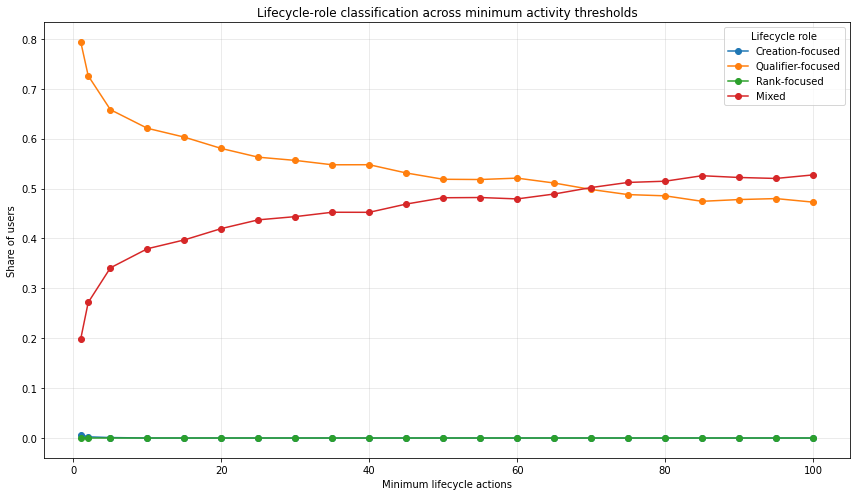

In [65]:
plot_cols = [
    "creation_focused_share",
    "qualifier_focused_share",
    "rank_focused_share",
    "mixed_share",
]

ax = role_sensitivity_results.set_index("min_lifecycle_actions")[plot_cols].plot(
    kind="line",
    marker="o",
    figsize=(12, 7)
)

ax.set_title("Lifecycle-role classification across minimum activity thresholds")
ax.set_xlabel("Minimum lifecycle actions")
ax.set_ylabel("Share of users")

ax.legend(
    [
        "Creation-focused",
        "Qualifier-focused",
        "Rank-focused",
        "Mixed",
    ],
    title="Lifecycle role"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.2 interpretation summary

Most constraint statements involve limited named-human participation. Including zero-human cases, 70.0% of curated constraints involve exactly one named human user, 13.6% involve no named human user after filtering, 11.1% involve two human users, and only 5.3% involve three or more.

Deleted constraints involve more human users on average than non-deleted constraints, but the median remains one user in both cases. This suggests that deletion is associated with somewhat higher lifecycle participation, but not necessarily broad collaboration.

At the user-role level, many recurring lifecycle participants are qualifier-focused. This indicates that constraint lifecycle work is not limited to initial constraint creation: a substantial part of human participation occurs through qualifier maintenance, where the operational meaning of constraints is specified.

Because rank rows may be created initially or changed later, rank activity is kept separate from both creation and qualifier maintenance.

## Interpretation of lifecycle roles

The lifecycle-role distribution is sensitive to very low-activity users, who are more likely to appear strongly concentrated by construction. At low thresholds, most users are classified as qualifier-focused.

However, the distribution stabilizes after approximately 20–30 lifecycle actions. Among recurring lifecycle participants, two persistent roles remain: qualifier-focused users and mixed contributors.

Qualifier-focused users contribute primarily through qualifier rows (`pq:*`), while mixed users participate across creation (`ps:P2302`), rank maintenance (`wikibase:rank`), and qualifier maintenance. Creation-focused and rank-focused users are nearly absent under this operational definition.

This suggests that constraint governance is not centered only on the initial creation of constraints. A substantial share of recurring participation occurs through ongoing qualifier maintenance, while many high-activity users combine creation and maintenance activities across the full lifecycle.

# 3.3 — Are there groups of users working on the same constraint type?

In 3.1, we examined whether individual users specialize in specific constraint types.

Now we move from individual specialization to collective structure:

> Do groups of users repeatedly work on the same kinds of constraints?

The goal is to identify whether constraint work is socially organized around particular constraint types.

For example:

- do the same users repeatedly work on `property scope constraint`?
- is `allowed qualifiers constraint` maintained by a distinct editor group?
- are some constraint types broadly shared while others are handled by small recurring communities?

This helps us understand whether constraint governance is distributed or clustered around specialized user groups.

In [66]:
import pandas as pd
import numpy as np

## Step 1 — Reuse human-created curated constraint additions

For this analysis, we focus on human-created curated constraint additions from 3.1.

Each row represents:

- one curated constraint creation
- one human creator
- one constraint type

In [67]:
df_human_constraint_additions.head()

,s,p,o,constraint_type,target_entity,target_entity_type,cdate,cuser,ddate,duser
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,distinct-values constraint,wd:P484,property,2016-09-24 13:47:32+00:00,Jura1,2017-07-13T04:20:20Z,KrBot
395,wds:P484-3127A57A-8D36-4FF5-9483-30D641657B7F,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2022-07-09 21:27:10+00:00,Lectrician1,2022-07-09T22:00:54Z,Lectrician1
398,wds:P484-60D89EFA-AFC8-4B07-868F-41AC990A078C,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2022-07-09 21:16:02+00:00,Lectrician1,2022-07-09T22:22:05Z,Lectrician1
536,wds:P484-B0908D50-E166-4661-B397-3D479A5003C1,ps:P2302,wd:Q52004125,allowed-entity-types constraint,wd:P484,property,2020-09-30 16:26:57+00:00,Lockal,NaN,NaN
544,wds:P484-da610a56-4ad5-7352-5d34-228c33cb6f4d,ps:P2302,wd:Q53869507,property scope constraint,wd:P484,property,2024-10-13 09:55:48+00:00,ChristianKl,NaN,NaN


## Step 2 — Build the user × constraint-type matrix

Rows are users.  
Columns are constraint types.

Each cell contains the number of curated constraint additions created by that user for that constraint type.

This lets us observe whether users cluster around particular types of constraints.

In [68]:
user_constraint_matrix = (
    df_human_constraint_additions
    .groupby(["cuser", "constraint_type"])
    .size()
    .unstack(fill_value=0)
)

user_constraint_matrix.head()

constraint_type,Commons link constraint,allowed qualifiers constraint,allowed units constraint,allowed-entity-types constraint,citation-needed constraint,conflicts-with constraint,contemporary constraint,description in language constraint,difference-within-range constraint,distinct-values constraint,...,one-of qualifier value property constraint,property scope constraint,range constraint,required qualifier constraint,single-best-value constraint,single-value constraint,subject type constraint,symmetric constraint,value-requires-statement constraint,value-type constraint
cuser,,,,,,,,,,,,,,,,,,,,,
-Zest,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,1,0,0,1,0
-akko,0,0,0,8,0,0,0,0,0,9,...,0,9,0,0,0,7,7,0,0,0
.hecko,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1-Byte,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,1,0,0,0
1997kB,0,0,0,2,0,0,0,0,0,4,...,0,3,1,0,0,3,3,0,0,0


## Step 3 — Count how many users work on each constraint type

This gives the basic participation size of each constraint type.

Some constraint types may be maintained by broad communities, while others may be handled by small recurring groups.

In [69]:
users_per_constraint_type = (
    (user_constraint_matrix > 0)
    .sum(axis=0)
    .sort_values(ascending=False)
    .rename("n_users")
    .reset_index()
    .rename(columns={"index": "constraint_type"})
)

users_per_constraint_type.head(20)

,constraint_type,n_users
0,item-requires-statement constraint,314
1,subject type constraint,306
2,property scope constraint,267
3,format constraint,252
4,distinct-values constraint,248
5,single-value constraint,244
6,allowed-entity-types constraint,227
7,conflicts-with constraint,187
8,value-type constraint,170
9,allowed qualifiers constraint,163


## Step 4 — Count how concentrated each constraint type is

For each constraint type, we calculate:

> What share of all additions comes from the single most active user?

This helps distinguish:

- distributed constraint types
- strongly concentrated constraint types dominated by a few editors

In [70]:
constraint_type_concentration = pd.DataFrame({
    "total_additions": user_constraint_matrix.sum(axis=0),
    "top_user_share": user_constraint_matrix.max(axis=0)
    / user_constraint_matrix.sum(axis=0),
    "n_users": (user_constraint_matrix > 0).sum(axis=0),
})

constraint_type_concentration = (
    constraint_type_concentration
    .sort_values("top_user_share", ascending=False)
)

constraint_type_concentration.head(20)

,total_additions,top_user_share,n_users
constraint_type,,,
contemporary constraint,298,0.755034,42
no-bounds constraint,89,0.528090,14
allowed-entity-types constraint,9423,0.475751,227
none-of constraint,867,0.452134,90
description in language constraint,36,0.388889,10
conflicts-with constraint,2127,0.371415,187
property scope constraint,9223,0.363981,267
citation-needed constraint,408,0.343137,84
lexeme-value-requires-lexical-category constraint,3,0.333333,3


## Step 5 — Identify the dominant user for each constraint type

This helps interpret whether concentration reflects real stewardship by specific users.

In [71]:
dominant_user_per_type = user_constraint_matrix.idxmax(axis=0)

constraint_type_concentration["dominant_user"] = dominant_user_per_type

constraint_type_concentration.head(20)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
contemporary constraint,298,0.755034,42,Abián
no-bounds constraint,89,0.528090,14,MisterSynergy
allowed-entity-types constraint,9423,0.475751,227,Lockal
none-of constraint,867,0.452134,90,Trade
description in language constraint,36,0.388889,10,Multichill
conflicts-with constraint,2127,0.371415,187,Trade
property scope constraint,9223,0.363981,267,Lockal
citation-needed constraint,408,0.343137,84,Trade
lexeme-value-requires-lexical-category constraint,3,0.333333,3,99of9


## Step 6 — Identify repeated co-participation between users

We now ask:

> Which users repeatedly work on the same constraint types?

We construct a simple co-participation network:

Two users are connected if both contributed to the same constraint type.

In [72]:
binary_user_constraint = (user_constraint_matrix > 0).astype(int)

user_user_overlap = (
    binary_user_constraint
    .dot(binary_user_constraint.T)
)

np.fill_diagonal(user_user_overlap.values, 0)

user_user_overlap.head()

cuser,-Zest,-akko,.hecko,1-Byte,1997kB,1Veertje,2le2im-bdc,4ing,99of9,A particle for world to form,...,わかき,"シェン,アーナリー,ン,アーバァ.",レオタード３世,慈居,本日晴天,沈澄心,白布飘扬,社会我佩奇,軽快,迴廊彼端
cuser,,,,,,,,,,,,,,,,,,,,,
-Zest,0,3,0,3,2,2,0,0,5,0,...,0,0,0,1,3,0,2,0,1,1
-akko,3,0,2,5,6,5,1,1,7,0,...,0,0,2,3,6,1,5,1,1,0
.hecko,0,2,0,0,2,2,1,0,2,0,...,0,0,2,2,1,0,2,0,0,0
1-Byte,3,5,0,0,4,3,0,1,5,0,...,0,0,0,1,5,1,3,1,1,0
1997kB,2,6,2,4,0,4,1,1,6,0,...,0,0,2,3,6,1,4,1,0,0


## Step 7 — Strong collaboration ties only

Many users may overlap once by chance.

To focus on stronger shared work patterns, we keep only pairs of users who overlap on at least 3 constraint types.

In [73]:
strong_ties = (
    user_user_overlap
    .rename_axis(index="user_1", columns="user_2")
    .stack()
    .reset_index(name="shared_constraint_types")
)

strong_ties = strong_ties.loc[
    strong_ties["shared_constraint_types"] >= 3
]

strong_ties = strong_ties.loc[
    strong_ties["user_1"] < strong_ties["user_2"]
]

strong_ties.sort_values(
    "shared_constraint_types",
    ascending=False
).head(30)

,user_1,user_2,shared_constraint_types
308651,Jura1,Pamputt,27
150669,Dhx1,Jura1,24
308500,Jura1,Kirilloparma,24
308555,Jura1,Manu1400,24
308582,Jura1,Midleading,24
17236,AdamSeattle,Pamputt,23
17069,AdamSeattle,Jura1,23
150836,Dhx1,Pamputt,23
367936,Manu1400,Pamputt,22
16880,AdamSeattle,Dhx1,22


## Step 8 — Constraint types with the strongest recurring editor groups

We identify constraint types where:

- many users participate
- activity is not dominated by one editor

These are likely the most collaborative constraint communities.

In [74]:
constraint_type_concentration.sort_values(
    ["n_users", "top_user_share"],
    ascending=[False, True]
).head(20)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
item-requires-statement constraint,7978,0.178491,314,Manu1400
subject type constraint,5852,0.205571,306,Pintoch
property scope constraint,9223,0.363981,267,Lockal
format constraint,6485,0.167309,252,Pintoch
distinct-values constraint,7359,0.207909,248,Pintoch
single-value constraint,5974,0.255608,244,Pintoch
allowed-entity-types constraint,9423,0.475751,227,Lockal
conflicts-with constraint,2127,0.371415,187,Trade
value-type constraint,728,0.097527,170,Jura1


## Step 9 — Constraint types dominated by a single editor

We also inspect the opposite case:

constraint types where one editor contributes a very large share of all additions.

These may represent stewardship, ownership, or highly specialized expertise.

In [75]:
constraint_type_concentration.sort_values(
    ["top_user_share", "total_additions"],
    ascending=[False, False]
).head(20)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
contemporary constraint,298,0.755034,42,Abián
no-bounds constraint,89,0.528090,14,MisterSynergy
allowed-entity-types constraint,9423,0.475751,227,Lockal
none-of constraint,867,0.452134,90,Trade
description in language constraint,36,0.388889,10,Multichill
conflicts-with constraint,2127,0.371415,187,Trade
property scope constraint,9223,0.363981,267,Lockal
citation-needed constraint,408,0.343137,84,Trade
lexeme-value-requires-lexical-category constraint,3,0.333333,3,99of9


## Interpretation target

This analysis answers:

> Is constraint governance socially distributed across many users, or concentrated around recurring editor groups?

We are especially looking for:

- broad collaborative constraint types
- concentrated steward-driven constraint types
- recurring groups of users who repeatedly work on the same constraint families

In [76]:
constraint_type_concentration.sort_values(
    "top_user_share",
    ascending=False
).head(20)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
contemporary constraint,298,0.755034,42,Abián
no-bounds constraint,89,0.528090,14,MisterSynergy
allowed-entity-types constraint,9423,0.475751,227,Lockal
none-of constraint,867,0.452134,90,Trade
description in language constraint,36,0.388889,10,Multichill
conflicts-with constraint,2127,0.371415,187,Trade
property scope constraint,9223,0.363981,267,Lockal
citation-needed constraint,408,0.343137,84,Trade
lexeme-value-requires-lexical-category constraint,3,0.333333,3,99of9


In [77]:
constraint_type_concentration.sort_values(
    ["n_users", "top_user_share"],
    ascending=[False, True]
).head(20)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
item-requires-statement constraint,7978,0.178491,314,Manu1400
subject type constraint,5852,0.205571,306,Pintoch
property scope constraint,9223,0.363981,267,Lockal
format constraint,6485,0.167309,252,Pintoch
distinct-values constraint,7359,0.207909,248,Pintoch
single-value constraint,5974,0.255608,244,Pintoch
allowed-entity-types constraint,9423,0.475751,227,Lockal
conflicts-with constraint,2127,0.371415,187,Trade
value-type constraint,728,0.097527,170,Jura1


In [78]:
strong_ties.sort_values(
    "shared_constraint_types",
    ascending=False
).head(30)

,user_1,user_2,shared_constraint_types
308651,Jura1,Pamputt,27
150669,Dhx1,Jura1,24
308500,Jura1,Kirilloparma,24
308555,Jura1,Manu1400,24
308582,Jura1,Midleading,24
17236,AdamSeattle,Pamputt,23
17069,AdamSeattle,Jura1,23
150836,Dhx1,Pamputt,23
367936,Manu1400,Pamputt,22
16880,AdamSeattle,Dhx1,22


In [79]:
users_per_constraint_type.head(20)

,constraint_type,n_users
0,item-requires-statement constraint,314
1,subject type constraint,306
2,property scope constraint,267
3,format constraint,252
4,distinct-values constraint,248
5,single-value constraint,244
6,allowed-entity-types constraint,227
7,conflicts-with constraint,187
8,value-type constraint,170
9,allowed qualifiers constraint,163


Constraint-type work is not uniformly organized.

Some constraint types are broadly distributed across many users, while others are strongly associated with a dominant user.

More concentrated:
- contemporary constraint: Abián created 75.8%
- no-bounds constraint: MisterSynergy created 52.8%
- allowed-entity-types constraint: Lockal created 47.6%
- none-of constraint: Trade created 45.3%

More distributed:
- value-type constraint: top user only 9.8%, 170 users
- allowed qualifiers constraint: top user only 12.1%, 163 users
- item-requires-statement constraint: top user 17.9%, 312 users
- format constraint: top user 16.7%, 252 users

## Interpretation

The results show two different forms of social organization around constraint types.

First, some constraint types are relatively concentrated around a dominant contributor. For example, `contemporary constraint` is strongly associated with Abián, who accounts for 75.8% of human-created additions of that type. Other relatively concentrated types include `no-bounds constraint`, `allowed-entity-types constraint`, and `none-of constraint`.

Second, several high-volume constraint types are broadly distributed across many users. `item-requires-statement constraint`, `subject type constraint`, `format constraint`, and `distinct-values constraint` each involve hundreds of users, and their most active contributor accounts for a comparatively small share of additions.

The user-user overlap results suggest the presence of a broad recurring constraint-editing core. Jura1 appears in many of the strongest overlap pairs, sharing many constraint types with users such as Pamputt, Dhx1, Midleading, Kirilloparma, and Manu1400. This indicates that some users work across many of the same constraint-type areas, rather than being isolated specialists in only one type.

## Robustness check: exclude rare constraint types

Some concentration scores are unstable for rare constraint types.

For example, a constraint type with only 3 additions can have a high top-user share for purely mechanical reasons.

We therefore repeat the concentration table using only constraint types with at least 100 human-created additions.

In [80]:
constraint_type_concentration_100 = constraint_type_concentration.loc[
    constraint_type_concentration["total_additions"] >= 100
].copy()

constraint_type_concentration_100.sort_values(
    "top_user_share",
    ascending=False
)

,total_additions,top_user_share,n_users,dominant_user
constraint_type,,,,
contemporary constraint,298,0.755034,42,Abián
allowed-entity-types constraint,9423,0.475751,227,Lockal
none-of constraint,867,0.452134,90,Trade
conflicts-with constraint,2127,0.371415,187,Trade
property scope constraint,9223,0.363981,267,Lockal
citation-needed constraint,408,0.343137,84,Trade
range constraint,270,0.322222,52,Manu1400
required qualifier constraint,803,0.306351,139,Trade
value-requires-statement constraint,475,0.258947,93,Jura1


## Plot: constraint-type concentration versus participation breadth

This plot shows whether constraint types are dominated by one user or distributed across many users.

The x-axis shows the number of human users contributing to a constraint type.  
The y-axis shows the share of additions made by the most active user.

Constraint types in the upper-left are more steward-like.  
Constraint types in the lower-right are more distributed.

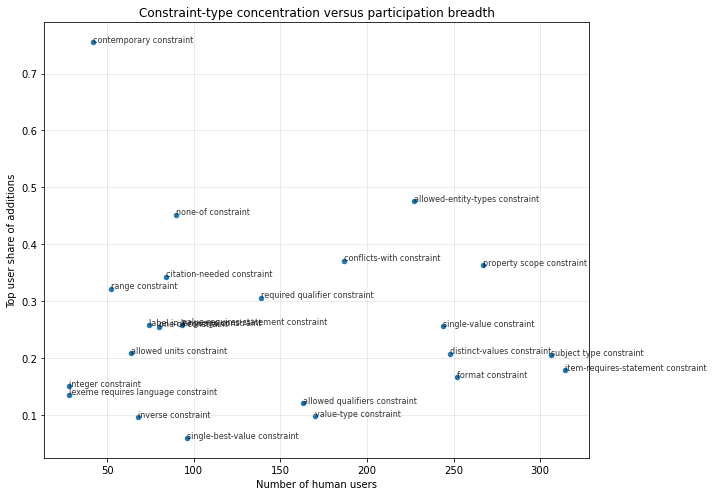

In [81]:
import matplotlib.pyplot as plt

plot_df = constraint_type_concentration_100.copy()

ax = plot_df.plot(
    kind="scatter",
    x="n_users",
    y="top_user_share",
    figsize=(10, 7)
)

for constraint_type, row in plot_df.iterrows():
    ax.annotate(
        constraint_type,
        (row["n_users"], row["top_user_share"]),
        fontsize=8,
        alpha=0.8
    )

ax.set_title("Constraint-type concentration versus participation breadth")
ax.set_xlabel("Number of human users")
ax.set_ylabel("Top user share of additions")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation

To avoid over-interpreting rare constraint types, we focus on constraint types with at least 100 human-created additions.

The plot separates constraint types into two broad patterns:

- concentrated or steward-like types, where one user accounts for a large share of additions
- distributed types, where many users contribute and no single user dominates

This supports the conclusion that constraint-type work is socially heterogeneous: some constraint types are associated with dominant contributors, while others are broadly distributed across many editors.

The robustness table removes the tiny rare types, and the pattern still holds:

Steward-like / concentrated:
- contemporary constraint
- allowed-entity-types constraint
- none-of constraint
- conflicts-with constraint
- property scope constraint

Distributed:
- item-requires-statement constraint
- subject type constraint
- format constraint
- value-type constraint
- allowed qualifiers constraint
- single-best-value constraint

## 3.3 interpretation summary

After excluding rare constraint types with fewer than 100 human-created additions, the results still show substantial variation in how constraint-type work is socially organized.

Some constraint types are relatively concentrated around a dominant contributor. For example, `contemporary constraint` is strongly dominated by one user, while `allowed-entity-types constraint`, `none-of constraint`, `conflicts-with constraint`, and `property scope constraint` also show comparatively high top-user shares.

Other constraint types are much more distributed. `item-requires-statement constraint`, `subject type constraint`, and `format constraint` involve hundreds of users, while their top-user shares remain below about 21%. Similarly, `value-type constraint`, `allowed qualifiers constraint`, and `single-best-value constraint` show low top-user shares despite substantial participation.

This suggests that constraint-type governance is socially heterogeneous. Some constraint types resemble steward-driven areas, while others are broadly distributed across many editors.

The user-overlap analysis further suggests the presence of a recurring core of constraint editors who work across many of the same constraint types. However, this overlap should be interpreted as shared participation in constraint-type areas, not necessarily direct coordination on the same individual constraint statements.

In [82]:
import pandas as pd
import numpy as np

## Step 1 — Reuse valid curated constraint statements

We again start from curated constraint statements identified by:

- `p == "ps:P2302"`
- curated constraint type

Each statement ID (`s`) represents one individual constraint instance.

In [83]:
len(valid_constraint_statements)

77277

## Step 2 — Keep the full lifecycle of each constraint

We include all rows attached to each valid constraint statement:

- creation row (`ps:P2302`)
- qualifier rows (`pq:*`)
- rank rows (`wikibase:rank`)
- later lifecycle edits

In [84]:
df_constraint_stability = df_constraints_clean.loc[
    df_constraints_clean["s"].isin(valid_constraint_statements)
].copy()

df_constraint_stability.head()

,s,p,o,cdate,cuser,ddate,duser
74,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,wikibase:rank,wikibase:NormalRank,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
75,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,ps:P2302,wd:Q21502410,2016-09-24T13:47:32Z,Jura1,2017-07-13T04:20:20Z,KrBot
76,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3817441,2017-07-13T04:20:45Z,KrBot,2017-07-13T23:44:20Z,KrBot
77,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3680919,2017-07-13T04:20:46Z,KrBot,2017-07-13T23:44:20Z,KrBot
78,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q11295066,2017-07-13T04:20:55Z,KrBot,2017-07-13T23:44:20Z,KrBot


## Step 3 — Count total lifecycle edits per constraint

We use the number of rows attached to a constraint statement as a first proxy for lifecycle activity.

More rows generally indicate more maintenance or revision.

In [85]:
rows_per_constraint = (
    df_constraint_stability
    .groupby("s")
    .size()
    .rename("total_rows")
    .reset_index()
)

rows_per_constraint.head()

,s,total_rows
0,wds:L1371386-419bce64-4e7b-117b-3eee-6f9dfd27a6f5,2
1,wds:L1371386-59f3cc5d-44f4-f113-2cd5-522e303cb9be,2
2,wds:P10-1529A843-91A8-4FEA-B43F-9A3258446A38,16
3,wds:P10-28240BCD-348B-45BD-9654-3B5B8E101FD6,4
4,wds:P10-7078A980-32E7-4103-B102-B8F9DFB507E8,15


## Step 4 — Distinguish complexity from evolution

A high number of qualifier rows does not necessarily mean that a constraint is unstable.

For example, a constraint may be created with many qualifiers and then remain unchanged.  
That would be complex, but stable.

Therefore, we separate:

- qualifier complexity: how many qualifier rows are attached to the constraint
- qualifier evolution: whether qualifier rows are added after the initial creation period

To do this, we compare qualifier creation timestamps to the creation timestamp of the constraint statement.

In [86]:
# Metadata from the constraint type row: one row per constraint statement
constraint_creation_metadata = (
    df_constraints_clean.loc[
        df_constraints_clean["p"].eq("ps:P2302")
        & df_constraints_clean["o"].isin(curated_constraint_qids),
        ["s", "o", "cdate", "ddate"]
    ]
    .copy()
)

constraint_creation_metadata["constraint_type"] = (
    constraint_creation_metadata["o"].map(constraint_type_map)
)

constraint_creation_metadata["constraint_cdate"] = pd.to_datetime(
    constraint_creation_metadata["cdate"],
    errors="coerce",
    utc=True
)

constraint_creation_metadata["constraint_ddate"] = pd.to_datetime(
    constraint_creation_metadata["ddate"],
    errors="coerce",
    utc=True
)

constraint_creation_metadata["is_deleted"] = (
    constraint_creation_metadata["constraint_ddate"].notna()
)

constraint_creation_metadata = constraint_creation_metadata[
    [
        "s",
        "constraint_type",
        "constraint_cdate",
        "constraint_ddate",
        "is_deleted",
    ]
]

## Step 5 — Extract qualifier rows and compare timestamps

We now keep only qualifier rows (`pq:*`) and calculate how long after the constraint creation each qualifier row was added.

This lets us distinguish qualifiers created together with the constraint from qualifiers added later.

In [87]:
df_qualifier_lifecycle = df_constraint_stability.loc[
    df_constraint_stability["p"].str.startswith("pq:", na=False),
    ["s", "p", "o", "cdate", "ddate", "cuser", "duser"]
].copy()

df_qualifier_lifecycle["qualifier_cdate"] = pd.to_datetime(
    df_qualifier_lifecycle["cdate"],
    errors="coerce",
    utc=True
)

df_qualifier_lifecycle["qualifier_ddate"] = pd.to_datetime(
    df_qualifier_lifecycle["ddate"],
    errors="coerce",
    utc=True
)

df_qualifier_lifecycle = df_qualifier_lifecycle.merge(
    constraint_creation_metadata[
        ["s", "constraint_cdate", "constraint_type"]
    ],
    on="s",
    how="left"
)

df_qualifier_lifecycle["days_after_constraint_creation"] = (
    (
        df_qualifier_lifecycle["qualifier_cdate"]
        - df_qualifier_lifecycle["constraint_cdate"]
    )
    .dt.total_seconds()
    / (60 * 60 * 24)
)

df_qualifier_lifecycle.head()

,s,p,o,cdate,ddate,cuser,duser,qualifier_cdate,qualifier_ddate,constraint_cdate,constraint_type,days_after_constraint_creation
0,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3817441,2017-07-13T04:20:45Z,2017-07-13T23:44:20Z,KrBot,KrBot,2017-07-13 04:20:45+00:00,2017-07-13 23:44:20+00:00,2017-07-13 04:20:26+00:00,single-value constraint,0.000220
1,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3680919,2017-07-13T04:20:46Z,2017-07-13T23:44:20Z,KrBot,KrBot,2017-07-13 04:20:46+00:00,2017-07-13 23:44:20+00:00,2017-07-13 04:20:26+00:00,single-value constraint,0.000231
2,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q11295066,2017-07-13T04:20:55Z,2017-07-13T23:44:20Z,KrBot,KrBot,2017-07-13 04:20:55+00:00,2017-07-13 23:44:20+00:00,2017-07-13 04:20:26+00:00,single-value constraint,0.000336
3,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q3743260,2017-07-13T04:21:00Z,2017-07-13T23:44:20Z,KrBot,KrBot,2017-07-13 04:21:00+00:00,2017-07-13 23:44:20+00:00,2017-07-13 04:20:26+00:00,single-value constraint,0.000394
4,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,pq:P2303,wd:Q408273,2017-07-13T04:20:41Z,2017-07-13T23:44:20Z,KrBot,KrBot,2017-07-13 04:20:41+00:00,2017-07-13 23:44:20+00:00,2017-07-13 04:20:26+00:00,single-value constraint,0.000174


## Step 6 — Define an initial creation window

Some qualifiers may be added minutes or hours after the `ps:P2302` row because of edit sequencing.

To avoid treating these as later evolution, we define an initial creation window.

Here we use 1 day as a conservative operational window: qualifier rows added within 1 day of the constraint creation are treated as part of the initial constraint setup.

This threshold should be reported as an operational choice, and we later test sensitivity to alternative windows.

In [88]:
initial_window_days = 1

df_qualifier_lifecycle["qualifier_added_after_initial_window"] = (
    df_qualifier_lifecycle["days_after_constraint_creation"] > initial_window_days
)

## Step 7 — Summarize qualifier complexity and evolution per constraint

For each constraint statement, we calculate:

- total qualifier rows
- qualifiers added during initial setup
- qualifiers added after the initial setup window
- whether any qualifier was deleted
- time span between first and last qualifier addition

This gives a better measure of whether the constraint evolved after creation.

In [89]:
qualifier_evolution_summary = (
    df_qualifier_lifecycle
    .groupby("s")
    .agg(
        n_qualifier_rows=("p", "size"),
        n_initial_qualifier_rows=(
            "qualifier_added_after_initial_window",
            lambda x: (~x).sum()
        ),
        n_later_qualifier_rows=(
            "qualifier_added_after_initial_window",
            "sum"
        ),
        has_deleted_qualifier=(
            "qualifier_ddate",
            lambda x: x.notna().any()
        ),
        first_qualifier_cdate=("qualifier_cdate", "min"),
        last_qualifier_cdate=("qualifier_cdate", "max"),
    )
    .reset_index()
)

qualifier_evolution_summary["qualifier_addition_span_days"] = (
    (
        qualifier_evolution_summary["last_qualifier_cdate"]
        - qualifier_evolution_summary["first_qualifier_cdate"]
    )
    .dt.total_seconds()
    / (60 * 60 * 24)
)

qualifier_evolution_summary.head()

,s,n_qualifier_rows,n_initial_qualifier_rows,n_later_qualifier_rows,has_deleted_qualifier,first_qualifier_cdate,last_qualifier_cdate,qualifier_addition_span_days
0,wds:P10-1529A843-91A8-4FEA-B43F-9A3258446A38,14,2,12,True,2017-07-13 07:27:22+00:00,2023-09-09 16:17:50+00:00,2249.368380
1,wds:P10-28240BCD-348B-45BD-9654-3B5B8E101FD6,2,2,0,False,2017-07-13 07:27:19+00:00,2017-07-13 07:27:20+00:00,0.000012
2,wds:P10-7078A980-32E7-4103-B102-B8F9DFB507E8,13,8,5,True,2017-07-13 07:27:24+00:00,2023-12-25 02:47:15+00:00,2355.805451
3,wds:P10-c6043ffd-45c6-add1-344d-f60fb046d83e,2,2,0,False,2020-11-29 20:16:07+00:00,2020-11-29 20:17:02+00:00,0.000637
4,wds:P10-c6b7afe3-407f-550a-9d38-b076c501acb0,3,2,1,False,2020-11-29 20:15:03+00:00,2021-06-25 05:50:53+00:00,207.399884


## Step 8 — Merge qualifier evolution with all curated constraints

Constraints with no qualifier rows are assigned zero qualifier complexity and zero qualifier evolution.

In [90]:
constraint_stability_summary = (
    constraint_creation_metadata
    .merge(
        qualifier_evolution_summary,
        on="s",
        how="left"
    )
)

for col in [
    "n_qualifier_rows",
    "n_initial_qualifier_rows",
    "n_later_qualifier_rows",
]:
    constraint_stability_summary[col] = (
        constraint_stability_summary[col]
        .fillna(0)
        .astype(int)
    )

constraint_stability_summary["has_deleted_qualifier"] = (
    constraint_stability_summary["has_deleted_qualifier"]
    .fillna(False)
)

constraint_stability_summary["qualifier_addition_span_days"] = (
    constraint_stability_summary["qualifier_addition_span_days"]
    .fillna(0)
)

constraint_stability_summary.head()

,s,constraint_type,constraint_cdate,constraint_ddate,is_deleted,n_qualifier_rows,n_initial_qualifier_rows,n_later_qualifier_rows,has_deleted_qualifier,first_qualifier_cdate,last_qualifier_cdate,qualifier_addition_span_days
0,wds:P484-9A3ED56E-DDC0-4A29-8DE0-4F0515FCAE89,distinct-values constraint,2016-09-24 13:47:32+00:00,2017-07-13 04:20:20+00:00,True,0,0,0,False,NaT,NaT,0.000000
1,wds:P484-BDA83256-130C-442C-B0DC-12E2C41CECE4,single-value constraint,2017-07-13 04:20:26+00:00,2017-07-13 23:44:20+00:00,True,65,65,0,True,2017-07-13 04:20:26+00:00,2017-07-13 04:21:07+00:00,0.000475
2,wds:P484-14C64E63-B5B0-4464-88BD-6227A8FE796F,format constraint,2017-07-13 04:20:22+00:00,2017-07-13 23:44:21+00:00,True,2,2,0,True,2017-07-13 04:20:22+00:00,2017-07-13 04:20:23+00:00,0.000012
3,wds:P484-50692A14-39F2-416F-B31A-071C8D6EADA0,single-value constraint,2017-07-13 23:44:27+00:00,2017-07-16 17:29:37+00:00,True,113,113,0,True,2017-07-13 23:44:28+00:00,2017-07-13 23:45:50+00:00,0.000949
4,wds:P484-BC75C143-FFAA-4998-8A62-C38DDC137E50,format constraint,2017-07-13 23:44:23+00:00,2017-07-16 17:29:38+00:00,True,2,2,0,True,2017-07-13 23:44:23+00:00,2017-07-13 23:44:24+00:00,0.000012


Stable:
- not deleted
- no later qualifier additions
- no deleted qualifiers

Evolving:
- later qualifier additions
- qualifier additions spread over time

Deleted:
- deleted constraint statement

In [91]:
constraint_stability_summary[
    [
        "n_qualifier_rows",
        "n_initial_qualifier_rows",
        "n_later_qualifier_rows",
        "qualifier_addition_span_days",
    ]
].describe()

,n_qualifier_rows,n_initial_qualifier_rows,n_later_qualifier_rows,qualifier_addition_span_days
count,80147.000000,80147.000000,80147.000000,80147.000000
mean,5.720102,3.627160,2.092942,191.727777
std,122.084513,80.678509,43.336834,525.698828
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,0.000000
75%,3.000000,2.000000,1.000000,1.320000
max,18870.000000,12576.000000,6294.000000,2849.733275


In [92]:
constraint_stability_summary["is_deleted"].value_counts(normalize=True)

False    0.830424
True     0.169576
Name: is_deleted, dtype: float64

In [93]:
constraint_stability_summary["has_deleted_qualifier"].value_counts(normalize=True)

False    0.711093
True     0.288907
Name: has_deleted_qualifier, dtype: float64

In [94]:
(
    constraint_stability_summary["n_later_qualifier_rows"]
    .gt(0)
    .value_counts(normalize=True)
)

False    0.732803
True     0.267197
Name: n_later_qualifier_rows, dtype: float64

In [95]:
pd.set_option("display.max_columns", None)

constraint_stability_summary.groupby("is_deleted")[
    [
        "n_qualifier_rows",
        "n_later_qualifier_rows",
        "qualifier_addition_span_days",
        "has_deleted_qualifier",
    ]
].describe()

n_qualifier_rows                                             \
                      count       mean         std  min  25%  50%  75%   
is_deleted                                                               
False               66556.0   3.059574   16.797119  0.0  1.0  2.0  3.0   
True                13591.0  18.748878  293.790298  0.0  0.0  2.0  4.0   

                    n_later_qualifier_rows                                  \
                max                  count      mean         std  min  25%   
is_deleted                                                                   
False        1638.0                66556.0  1.068769    9.051495  0.0  0.0   
True        18870.0                13591.0  7.108381  103.171268  0.0  0.0   

                             qualifier_addition_span_days              \
            50%  75%     max                        count        mean   
is_deleted                                                              
False       0.0  0.0  1066.0                      66556.0  193.275300   
True        0.0  1.0  6294.0                      13591.0  184.149452   

                                                              
                   std  min  25%  50%       75%          max  
is_deleted                                                    
False       530.754693  0.0  0.0  0.0  0.003194  2849.733275  
True        500.152252  0.0  0.0  0.0  3.360266  2849.733275

In [96]:
stability_by_type = (
    constraint_stability_summary
    .groupby("constraint_type")
    .agg(
        n_constraints=("s", "size"),
        deletion_rate=("is_deleted", "mean"),
        later_qualifier_rate=("n_later_qualifier_rows", lambda x: (x > 0).mean()),
        deleted_qualifier_rate=("has_deleted_qualifier", "mean"),
        mean_qualifier_rows=("n_qualifier_rows", "mean"),
        mean_later_qualifier_rows=("n_later_qualifier_rows", "mean"),
        median_qualifier_span_days=("qualifier_addition_span_days", "median"),
    )
    .sort_values(
        ["later_qualifier_rate", "deletion_rate"],
        ascending=False
    )
)

stability_by_type.head(20)

,n_constraints,deletion_rate,later_qualifier_rate,deleted_qualifier_rate,mean_qualifier_rows,mean_later_qualifier_rows,median_qualifier_span_days
constraint_type,,,,,,,
allowed qualifiers constraint,1030,0.163107,0.686408,0.468932,31.507767,19.128155,574.825150
one-of constraint,333,0.369369,0.603604,0.660661,108.261261,48.222222,322.876979
value-type constraint,1246,0.203050,0.556180,0.609149,12.690209,5.842697,204.253976
subject type constraint,7957,0.179465,0.481966,0.457207,6.847556,2.676009,0.054745
format constraint,8360,0.058971,0.438397,0.513756,3.597129,1.616388,0.001285
single-best-value constraint,304,0.217105,0.401316,0.282895,23.598684,13.608553,0.000000
value-requires-statement constraint,663,0.484163,0.401207,0.580694,16.214178,5.286576,0.000012
allowed units constraint,669,0.312407,0.391629,0.518685,12.242152,6.400598,0.000012
difference-within-range constraint,23,0.478261,0.391304,0.608696,5.695652,2.000000,0.000000


- 73.3% have no later qualifier additions
- 26.7% have at least one later qualifier addition
- 16.9% are deleted
- 28.9% have at least one deleted qualifier

In [97]:
constraint_stability_summary[
    [
        "n_qualifier_rows",
        "n_later_qualifier_rows",
        "qualifier_addition_span_days",
    ]
].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

,n_qualifier_rows,n_later_qualifier_rows,qualifier_addition_span_days
0.50,2.0,0.0,0.000000
0.75,3.0,1.0,1.320000
0.90,6.0,2.0,743.380069
0.95,10.0,5.0,1530.686642
0.99,57.0,29.0,2591.634294


## Sensitivity analysis for the initial setup window

The distinction between initial setup and later evolution depends on the size of the initial creation window.

A one-day window is useful because qualifier rows may be added shortly after the `ps:P2302` row due to edit sequencing. However, this is an operational choice.

To avoid relying on a single window, we repeat the analysis using multiple windows:

- 0 days: only qualifiers at the exact creation timestamp count as initial setup
- 1 day
- 7 days
- 30 days

If the main pattern remains similar across windows, the conclusion is more robust.

In [98]:
initial_windows = [0, 1, 7, 30]

window_sensitivity_results = []

for window in initial_windows:
    temp = df_qualifier_lifecycle.copy()

    temp["later_qualifier"] = (
        temp["days_after_constraint_creation"] > window
    )

    temp_summary = (
        temp
        .groupby("s")
        .agg(
            n_later_qualifier_rows=("later_qualifier", "sum"),
            has_later_qualifier=("later_qualifier", "any"),
        )
        .reset_index()
    )

    all_constraints_temp = (
        constraint_creation_metadata[["s", "is_deleted"]]
        .merge(temp_summary, on="s", how="left")
    )

    all_constraints_temp["n_later_qualifier_rows"] = (
        all_constraints_temp["n_later_qualifier_rows"]
        .fillna(0)
        .astype(int)
    )

    all_constraints_temp["has_later_qualifier"] = (
        all_constraints_temp["has_later_qualifier"]
        .fillna(False)
    )

    window_sensitivity_results.append({
        "initial_window_days": window,
        "n_constraints": len(all_constraints_temp),
        "share_with_later_qualifier": all_constraints_temp["has_later_qualifier"].mean(),
        "median_later_qualifier_rows": all_constraints_temp["n_later_qualifier_rows"].median(),
        "p75_later_qualifier_rows": all_constraints_temp["n_later_qualifier_rows"].quantile(0.75),
        "p90_later_qualifier_rows": all_constraints_temp["n_later_qualifier_rows"].quantile(0.90),
        "p95_later_qualifier_rows": all_constraints_temp["n_later_qualifier_rows"].quantile(0.95),
    })

window_sensitivity_results = pd.DataFrame(window_sensitivity_results)

window_sensitivity_results

,initial_window_days,n_constraints,share_with_later_qualifier,median_later_qualifier_rows,p75_later_qualifier_rows,p90_later_qualifier_rows,p95_later_qualifier_rows
0,0,80147,0.525859,1.0,2.0,4.0,7.0
1,1,80147,0.267197,0.0,1.0,2.0,5.0
2,7,80147,0.235280,0.0,0.0,2.0,5.0
3,30,80147,0.209091,0.0,0.0,2.0,4.0


## Plot: sensitivity to the initial setup window

This plot shows how the estimated share of constraints with later qualifier evolution changes as the setup window becomes more permissive.

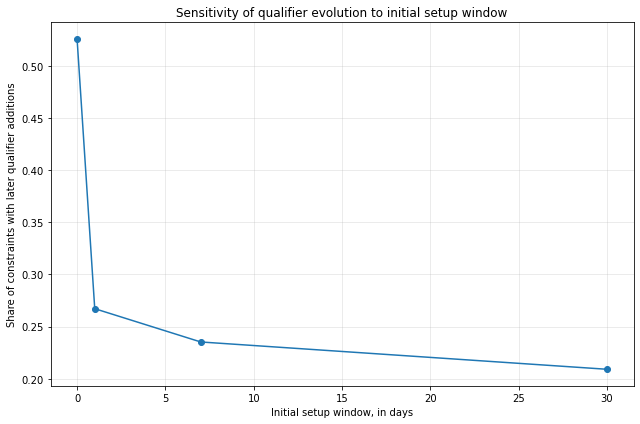

In [99]:
ax = window_sensitivity_results.plot(
    kind="line",
    x="initial_window_days",
    y="share_with_later_qualifier",
    marker="o",
    figsize=(9, 6),
    legend=False
)

ax.set_title("Sensitivity of qualifier evolution to initial setup window")
ax.set_xlabel("Initial setup window, in days")
ax.set_ylabel("Share of constraints with later qualifier additions")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final remarks for RQ3 — Historical dynamics of Wikidata property constraints

This section examined the social organization and temporal stability of Wikidata property constraints through four complementary questions.

---

## 3.1 Do users specialize in constraint types, properties, or lexemes?

Most high-activity human contributors behave as generalists rather than narrow specialists.

After excluding bots and applying a minimum activity threshold to avoid one-off concentration effects, most users distribute their constraint additions across multiple constraint types and target entities. Constraint-type specialists exist, but they are a minority, while strong target-entity specialists are rare.

This suggests that sustained constraint work is typically performed by broadly engaged editors rather than highly isolated specialists.

---

## 3.2 How many users participate in a constraint lifecycle?

Most constraints involve limited named-human participation.

Including zero-human cases after filtering bots, IP users, and missing users, most curated constraints involve exactly one named human editor, while only a small minority involve broader collaboration with three or more human participants.

Deleted constraints involve somewhat more human participation on average, but the median remains one user in both deleted and non-deleted cases.

At the lifecycle-role level, two stable roles emerge among recurring contributors:

- qualifier-focused maintainers
- mixed contributors spanning creation, rank, and qualifier work

This shows that constraint governance is not limited to initial creation. A substantial share of recurring participation occurs through qualifier maintenance, where the operational meaning of constraints is refined.

---

## 3.3 Are there groups of users working on the same constraint type?

Constraint-type work is socially heterogeneous.

Some constraint types are strongly concentrated around dominant contributors, resembling steward-driven areas of governance. Others are broadly distributed across hundreds of users, with low top-user concentration and wider participation.

User-overlap patterns further reveal a recurring core of experienced constraint editors who repeatedly work across many of the same constraint types.

This suggests that constraint governance combines both stewardship and distributed collaborative maintenance.

---

## 3.4 Are constraints stable or constantly changing?

Most constraints appear stable after initial setup.

Once the initial setup window is accounted for, most constraints do not receive later qualifier additions. The median constraint has zero later qualifier rows, and deletion affects a minority of cases.

However, a substantial minority of constraints continue to evolve, and this evolution is highly concentrated in a small number of constraint statements with long qualifier lifecycles and repeated edits.

Constraint stability also varies by constraint type. Some types involving allowed values and qualifier specifications show substantially more ongoing refinement than others.

This indicates that constraint governance is usually stable, but not static: most constraints settle quickly, while a smaller set remains under continuous refinement.

---

## Overall conclusion

Wikidata constraint governance is neither purely centralized nor purely collaborative.

It combines:

- broad generalist contributors rather than narrow specialists
- small-scale lifecycle participation rather than large collaborative crowds
- recurring editor cores for specific constraint families
- mostly stable constraints with localized areas of intense revision

Constraint maintenance therefore resembles a form of distributed expert stewardship: a relatively small but recurring set of contributors shapes both the creation and long-term operational meaning of constraints.

Several threats to validity remain. Bot detection relies on a curated list and username heuristics, which may miss non-obvious bot accounts or misclassify human users with bot-like names. The curated list should therefore be interpreted as an approximate filter rather than a complete ground truth.

The specialization classifications are also operational. Maximum-share scores are sensitive to small sample sizes, and the 70% threshold is not validated against an external ground truth. For this reason, threshold-based classes are used descriptively, while the sensitivity analyses provide the main evidence.

Lifecycle participation measures the breadth of human involvement, not the intensity or quality of collaboration. A user who adds one qualifier and a user who repeatedly maintains a constraint both count as participants. Similarly, co-participation in the same constraint types indicates shared areas of activity, not necessarily direct coordination or communication.

Finally, missing deletion users should not be treated as invalid in general: for active constraints, missing `duser` usually means that the constraint has not been deleted. Creator-deleter analyses therefore apply only to deleted constraints or rows with observed deletion metadata.